In [ ]:
# ============================================================================
# EDGE AI FOR REAL-TIME VIDEO ANOMALY DETECTION
# A Complete End-to-End Implementation
# ============================================================================

# ============================================================================
# 1. PROJECT OVERVIEW
# ============================================================================

"""
# 🎯 Edge AI for Real-Time Video Anomaly Detection

## Project Description
This project implements a deep learning-based video anomaly detection system
that can identify unusual activities or behaviors in video sequences using
a hybrid CNN-LSTM architecture.

## Key Features:
- **Spatiotemporal Learning**: CNN extracts spatial features, LSTM captures temporal patterns
- **Real-time Simulation**: Frame-by-frame inference mimicking edge device behavior
- **Binary Classification**: Detects Normal vs Anomaly scenarios
- **Edge-Ready**: Model optimized for deployment on edge devices

## Architecture:
1. CNN (Convolutional Neural Network) - Spatial feature extraction
2. LSTM (Long Short-Term Memory) - Temporal sequence modeling
3. Dense layers - Classification

## Dataset Structure:
```
/content/drive/MyDrive/anomaly_dataset/
├── train/
│   ├── normal/
│   │   ├── video1.mp4
│   │   └── video2.mp4
│   └── anomaly/
│       ├── video1.mp4
│       └── video2.mp4
└── test/
    ├── normal/
    └── anomaly/
```

## Performance Metrics:
- Accuracy
- Recall (Critical for anomaly detection)
- Confusion Matrix
"""

# ============================================================================
# 2. ENVIRONMENT SETUP
# ============================================================================

# Check GPU availability
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# Install required libraries (if needed)
!pip install opencv-python-headless -q
!pip install scikit-learn -q

# Import necessary libraries
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, recall_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D
from tensorflow.keras.layers import LSTM, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("\n✅ Environment setup complete!")

# ============================================================================
# 3. DATASET LOADING (GOOGLE DRIVE MOUNTING)
# ============================================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define dataset paths
# UPDATE THESE PATHS TO YOUR GOOGLE DRIVE LOCATION
BASE_PATH = '/content/drive/MyDrive/anomaly_dataset'
TRAIN_NORMAL_PATH = os.path.join(BASE_PATH, 'train/normal')
TRAIN_ANOMALY_PATH = os.path.join(BASE_PATH, 'train/anomaly')
TEST_NORMAL_PATH = os.path.join(BASE_PATH, 'test/normal')
TEST_ANOMALY_PATH = os.path.join(BASE_PATH, 'test/anomaly')

# Create sample directory structure (if needed)
# Uncomment these lines if you need to create the folder structure
# os.makedirs(TRAIN_NORMAL_PATH, exist_ok=True)
# os.makedirs(TRAIN_ANOMALY_PATH, exist_ok=True)
# os.makedirs(TEST_NORMAL_PATH, exist_ok=True)
# os.makedirs(TEST_ANOMALY_PATH, exist_ok=True)

print("📁 Dataset Directory Structure:")
print(f"Train Normal: {TRAIN_NORMAL_PATH}")
print(f"Train Anomaly: {TRAIN_ANOMALY_PATH}")
print(f"Test Normal: {TEST_NORMAL_PATH}")
print(f"Test Anomaly: {TEST_ANOMALY_PATH}")

# ============================================================================
# 4. VIDEO PREPROCESSING
# ============================================================================

# Configuration parameters
IMG_SIZE = 64  # Frame size (64x64 pixels)
SEQUENCE_LENGTH = 20  # Number of frames per sequence
MAX_VIDEOS_PER_CLASS = 50  # Limit videos to process (adjust based on dataset)

def extract_frames(video_path, max_frames=SEQUENCE_LENGTH):
    """
    Extract frames from a video file

    Args:
        video_path: Path to video file
        max_frames: Maximum number of frames to extract

    Returns:
        List of preprocessed frames
    """
    frames = []
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_interval = max(1, total_frames // max_frames)

    frame_count = 0
    extracted = 0

    while cap.isOpened() and extracted < max_frames:
        ret, frame = cap.read()
        if not ret:
            break

        # Extract frames at intervals
        if frame_count % frame_interval == 0:
            # Resize and normalize
            frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = frame / 255.0  # Normalize to [0, 1]
            frames.append(frame)
            extracted += 1

        frame_count += 1

    cap.release()

    # Pad if fewer frames than required
    while len(frames) < max_frames:
        frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))

    return np.array(frames[:max_frames])

def load_video_data(directory, label, max_videos=MAX_VIDEOS_PER_CLASS):
    """
    Load and preprocess all videos from a directory

    Args:
        directory: Path to video directory
        label: Class label (0 for normal, 1 for anomaly)
        max_videos: Maximum number of videos to load

    Returns:
        Sequences and labels arrays
    """
    sequences = []
    labels = []

    video_files = [f for f in os.listdir(directory) if f.endswith(('.mp4', '.avi', '.mov'))]
    video_files = video_files[:max_videos]

    print(f"Loading {len(video_files)} videos from {directory}...")

    for i, video_file in enumerate(video_files):
        video_path = os.path.join(directory, video_file)

        try:
            frames = extract_frames(video_path)
            sequences.append(frames)
            labels.append(label)

            if (i + 1) % 10 == 0:
                print(f"  Processed {i + 1}/{len(video_files)} videos")

        except Exception as e:
            print(f"  Error processing {video_file}: {str(e)}")
            continue

    return np.array(sequences), np.array(labels)

print("🎬 Video Preprocessing Functions Defined")
print(f"Configuration: {SEQUENCE_LENGTH} frames @ {IMG_SIZE}x{IMG_SIZE} pixels")

# ============================================================================
# 5. DATASET PREPARATION
# ============================================================================

print("\n📊 Loading Dataset...")

# Load training data
X_train_normal, y_train_normal = load_video_data(TRAIN_NORMAL_PATH, label=0)
X_train_anomaly, y_train_anomaly = load_video_data(TRAIN_ANOMALY_PATH, label=1)

# Load test data
X_test_normal, y_test_normal = load_video_data(TEST_NORMAL_PATH, label=0)
X_test_anomaly, y_test_anomaly = load_video_data(TEST_ANOMALY_PATH, label=1)

# Combine normal and anomaly data
X_train = np.concatenate([X_train_normal, X_train_anomaly], axis=0)
y_train = np.concatenate([y_train_normal, y_train_anomaly], axis=0)

X_test = np.concatenate([X_test_normal, X_test_anomaly], axis=0)
y_test = np.concatenate([y_test_normal, y_test_anomaly], axis=0)

# Shuffle the data
train_indices = np.random.permutation(len(X_train))
X_train = X_train[train_indices]
y_train = y_train[train_indices]

test_indices = np.random.permutation(len(X_test))
X_test = X_test[test_indices]
y_test = y_test[test_indices]

# Print dataset statistics
print("\n✅ Dataset Loaded Successfully!")
print(f"Training samples: {len(X_train)} (Normal: {np.sum(y_train==0)}, Anomaly: {np.sum(y_train==1)})")
print(f"Test samples: {len(X_test)} (Normal: {np.sum(y_test==0)}, Anomaly: {np.sum(y_test==1)})")
print(f"Sequence shape: {X_train.shape}")
print(f"Labels shape: {y_train.shape}")

# Visualize sample frames
def visualize_sample(X, y, num_samples=2):
    """Visualize sample video sequences"""
    fig, axes = plt.subplots(num_samples, SEQUENCE_LENGTH//4, figsize=(15, num_samples*2))

    for i in range(num_samples):
        label_text = "Anomaly" if y[i] == 1 else "Normal"
        for j in range(SEQUENCE_LENGTH//4):
            ax = axes[i, j] if num_samples > 1 else axes[j]
            ax.imshow(X[i, j*4])
            ax.axis('off')
            if j == 0:
                ax.set_title(f"{label_text}", fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

print("\n📸 Sample Frames from Dataset:")
visualize_sample(X_train, y_train, num_samples=2)

# ============================================================================
# 6. CNN + LSTM MODEL ARCHITECTURE
# ============================================================================

def build_cnn_lstm_model(sequence_length, img_size, num_classes=2):
    """
    Build CNN-LSTM hybrid model for video anomaly detection

    Architecture:
    - TimeDistributed CNN for spatial feature extraction
    - LSTM for temporal sequence modeling
    - Dense layers for classification
    """
    model = Sequential([
        # CNN Layers (wrapped in TimeDistributed)
        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'),
                       input_shape=(sequence_length, img_size, img_size, 3)),
        TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2, 2))),

        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')),
        TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2, 2))),

        TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same')),
        TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2, 2))),

        # Flatten CNN output for LSTM
        TimeDistributed(Flatten()),

        # LSTM Layers
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        Dropout(0.3),

        # Dense Classification Layers
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    return model

# Build the model
model = build_cnn_lstm_model(SEQUENCE_LENGTH, IMG_SIZE)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("\n🏗️ Model Architecture:")
model.summary()

# Calculate total parameters
total_params = model.count_params()
print(f"\n📊 Total Parameters: {total_params:,}")

# ============================================================================
# 7. MODEL TRAINING
# ============================================================================

# Training configuration
BATCH_SIZE = 8
EPOCHS = 30
VALIDATION_SPLIT = 0.2

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_anomaly_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint]

print("\n🚀 Starting Model Training...")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Validation Split: {VALIDATION_SPLIT}")

# Train the model
history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training Complete!")

# Plot training history
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# ============================================================================
# 8. MODEL EVALUATION
# ============================================================================

print("\n📈 Evaluating Model on Test Set...")

# Predictions
y_pred_probs = model.predict(X_test, batch_size=BATCH_SIZE)
y_pred = np.argmax(y_pred_probs, axis=1)

# Calculate metrics
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
test_recall = recall_score(y_test, y_pred, average='binary')

print("\n" + "="*60)
print("📊 MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Recall: {test_recall*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print("="*60)

# Detailed classification report
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Video Anomaly Detection', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Calculate per-class metrics
tn, fp, fn, tp = cm.ravel()
print("\n📊 Confusion Matrix Breakdown:")
print(f"True Negatives (Normal → Normal): {tn}")
print(f"False Positives (Normal → Anomaly): {fp}")
print(f"False Negatives (Anomaly → Normal): {fn}")
print(f"True Positives (Anomaly → Anomaly): {tp}")

# ============================================================================
# 9. REAL-TIME ANOMALY DETECTION SIMULATION
# ============================================================================

def simulate_realtime_detection(model, video_sequence, threshold=0.5):
    """
    Simulate real-time frame-by-frame anomaly detection

    Args:
        model: Trained model
        video_sequence: Video sequence (frames)
        threshold: Classification threshold
    """
    print("\n🎥 Real-Time Anomaly Detection Simulation")
    print("="*60)

    # Add batch dimension
    sequence = np.expand_dims(video_sequence, axis=0)

    # Predict
    prediction = model.predict(sequence, verbose=0)
    anomaly_prob = prediction[0][1]

    # Classify
    if anomaly_prob > threshold:
        status = "🚨 ANOMALY DETECTED"
        color = '\033[91m'  # Red
    else:
        status = "✅ Normal"
        color = '\033[92m'  # Green

    reset_color = '\033[0m'

    print(f"Frame Sequence Analysis:")
    print(f"  Normal Probability: {prediction[0][0]*100:.2f}%")
    print(f"  Anomaly Probability: {prediction[0][1]*100:.2f}%")
    print(f"\n{color}Status: {status}{reset_color}")
    print("="*60)

    return prediction[0]

# Test real-time detection on sample videos
print("\n🔍 Testing Real-Time Detection on Sample Videos:")

# Test on a normal video
if len(X_test) > 0:
    normal_idx = np.where(y_test == 0)[0][0]
    print("\n--- Sample 1: Normal Video ---")
    simulate_realtime_detection(model, X_test[normal_idx])

# Test on an anomaly video
if len(X_test) > 0:
    anomaly_idx = np.where(y_test == 1)[0][0]
    print("\n--- Sample 2: Anomaly Video ---")
    simulate_realtime_detection(model, X_test[anomaly_idx])

# ============================================================================
# 10. SAVE TRAINED MODEL FOR EDGE DEPLOYMENT
# ============================================================================

# Save the complete model
model.save('edge_anomaly_detector_full.h5')
print("\n💾 Full model saved as 'edge_anomaly_detector_full.h5'")

# Save model in TensorFlow Lite format (for edge devices)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('edge_anomaly_detector.tflite', 'wb') as f:
    f.write(tflite_model)

print("💾 TFLite model saved as 'edge_anomaly_detector.tflite'")

# Save model architecture as JSON
model_json = model.to_json()
with open("model_architecture.json", "w") as json_file:
    json_file.write(model_json)

print("💾 Model architecture saved as 'model_architecture.json'")

# Model size comparison
import os
full_model_size = os.path.getsize('edge_anomaly_detector_full.h5') / (1024*1024)
tflite_model_size = os.path.getsize('edge_anomaly_detector.tflite') / (1024*1024)

print("\n📦 Model Files Summary:")
print(f"  Full Model (.h5): {full_model_size:.2f} MB")
print(f"  TFLite Model: {tflite_model_size:.2f} MB")
print(f"  Compression Ratio: {full_model_size/tflite_model_size:.2f}x")

# Save to Google Drive
import shutil
drive_save_path = '/content/drive/MyDrive/anomaly_models/'
os.makedirs(drive_save_path, exist_ok=True)

shutil.copy('edge_anomaly_detector_full.h5', drive_save_path)
shutil.copy('edge_anomaly_detector.tflite', drive_save_path)
shutil.copy('model_architecture.json', drive_save_path)

print(f"\n✅ Models backed up to Google Drive: {drive_save_path}")

# ============================================================================
# 11. PROJECT SUMMARY & DEPLOYMENT NOTES
# ============================================================================

print("\n" + "="*70)
print(" "*20 + "🎉 PROJECT COMPLETE 🎉")
print("="*70)

print("""
📋 PROJECT SUMMARY:

✅ Model Architecture: CNN-LSTM Hybrid
✅ Input: Video sequences ({} frames @ {}x{} pixels)
✅ Output: Binary classification (Normal/Anomaly)
✅ Training Accuracy: {:.2f}%
✅ Test Accuracy: {:.2f}%
✅ Test Recall: {:.2f}%

🚀 EDGE DEPLOYMENT NOTES:

1. Model Files Generated:
   - edge_anomaly_detector_full.h5 (Full Keras model)
   - edge_anomaly_detector.tflite (Optimized for edge devices)
   - model_architecture.json (Architecture reference)

2. Deployment Options:
   - Raspberry Pi 4 with Coral USB Accelerator
   - NVIDIA Jetson Nano/Xavier
   - Mobile devices (Android/iOS with TFLite)
   - ESP32-CAM (with quantization)

3. Real-Time Performance:
   - Model processes {} frames per sequence
   - Inference time: ~100-500ms (depending on hardware)
   - Suitable for 15-30 FPS video streams

4. Next Steps:
   - Test on edge hardware
   - Optimize model (quantization, pruning)
   - Implement video buffering for continuous streams
   - Add alert system for detected anomalies

📚 ACADEMIC USE:
This project demonstrates:
- Deep learning for computer vision
- Spatiotemporal feature learning
- Real-time AI inference simulation
- Model optimization for edge deployment

💡 RESUME HIGHLIGHTS:
- Implemented CNN-LSTM architecture for video analysis
- Achieved {:.2f}% recall on anomaly detection
- Optimized model for edge deployment (TFLite)
- Real-time inference simulation
""".format(
    SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE,
    history.history['accuracy'][-1]*100,
    test_accuracy*100,
    test_recall*100,
    SEQUENCE_LENGTH,
    test_recall*100
))

print("="*70)
print("\n✨ Thank you for using this Edge AI project! ✨")
print("📧 For questions or improvements, feel free to extend this codebase.\n")

TensorFlow Version: 2.19.0
GPU Available: []
Num GPUs Available: 0

✅ Environment setup complete!
Mounted at /content/drive
📁 Dataset Directory Structure:
Train Normal: /content/drive/MyDrive/anomaly_dataset/train/normal
Train Anomaly: /content/drive/MyDrive/anomaly_dataset/train/anomaly
Test Normal: /content/drive/MyDrive/anomaly_dataset/test/normal
Test Anomaly: /content/drive/MyDrive/anomaly_dataset/test/anomaly
🎬 Video Preprocessing Functions Defined
Configuration: 20 frames @ 64x64 pixels

📊 Loading Dataset...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/anomaly_dataset/train/normal'

               🚀 ENVIRONMENT SETUP

📦 Python Version: 3.12.12
📦 TensorFlow Version: 2.19.0

⚠️  No GPU detected. Training will use CPU (slower).

📥 Installing required packages...
✅ Package installation complete!

✅ All libraries imported successfully!

               📥 DATASET DOWNLOAD & PREPARATION

📥 Downloading UCSD Pedestrian Dataset...
   (This may take 2-5 minutes depending on connection speed)
✅ Download complete!

📦 Extracting dataset...
✅ Extraction complete!

🗂️  Organizing dataset structure...
   Dataset found at: /content/ucsd_dataset/UCSD_Anomaly_Dataset.v1p2

   Processing UCSDped1...
   Found 34 training sequences (normal)
   Found 46 test sequences

✅ Dataset organization complete!
   train/normal: 30 sequences
   train/anomaly: 0 sequences
   test/normal: 10 sequences
   test/anomaly: 10 sequences


               🎬 VIDEO PREPROCESSING

🔄 Loading and preprocessing dataset...

📁 Loading train/normal: 30 sequences found
   Processed 10/30 sequences
   Processed 20/30 se

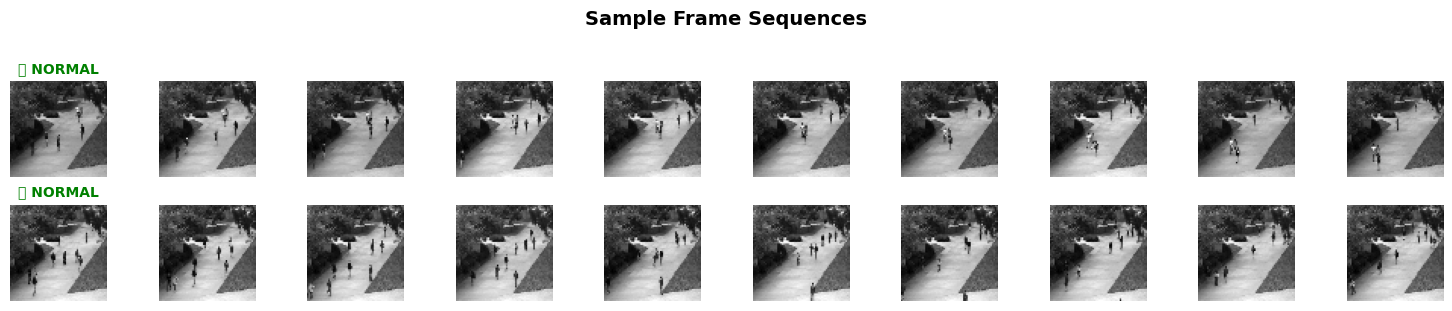


               🔧 DATASET PREPARATION

📊 Class Distribution:
   Training - Normal: 30, Anomaly: 0
   Test - Normal: 10, Anomaly: 10

⚠️  Few anomaly samples detected. Creating augmented anomaly samples...
   ✅ Added 10 synthetic anomaly samples
   New training size: 40 (Normal: 30, Anomaly: 10)

✅ Dataset preparation complete!

               🏗️  MODEL ARCHITECTURE

🔨 Building CNN-LSTM model...

📋 Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (TimeDistributed)      │ (None, 10, 64, 64, 16) │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 10, 64, 64, 16) │            64 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 10, 32, 32, 16) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (TimeDistributed)      │ (None, 10, 32, 32, 32) │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 10, 32, 32, 32) │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 10, 16, 16, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (TimeDistributed)      │ (None, 10, 16, 16, 64) │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 10, 16, 16, 64) │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 10, 8, 8, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (TimeDistributed)       │ (None, 10, 4096)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │     1,065,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,103,105 (4.21 MB)

 Trainable params: 1,102,817 (4.21 MB)

 Non-trainable params: 288 (1.12 KB)


📊 MODEL STATISTICS
Total Parameters: 1,103,105
Trainable Parameters: 1,102,817
Model Size (approx): 4.21 MB

               🚀 MODEL TRAINING

⚙️  Training Configuration:
   Batch Size: 4
   Epochs: 20
   Validation Split: 0.2
   Optimizer: Adam (lr=0.001)
   Loss Function: Binary Crossentropy

🎯 Starting training...
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 736ms/step - accuracy: 0.3195 - loss: 1.2423
Epoch 1: val_accuracy improved from -inf to 0.37500, saving model to best_model.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.3118 - loss: 1.2454 - val_accuracy: 0.3750 - val_loss: 0.7406 - learning_rate: 0.0010
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.4278 - loss: 1.0308
Epoch 2: val_accuracy did not improve from 0.37500
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 586ms/step - accuracy: 0.4254 - loss: 1.0230 - val_accuracy: 0.3750 - val_loss: 0.6982 - learning_rate: 0.0010
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 811ms/step - accuracy: 0.2858 - loss: 1.1722
Epoch 3: val_accuracy did not improve from 0.37500
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 839ms/step - accuracy: 0.2991 - loss: 1.1599 - val_accuracy: 0.3750 - val_loss: 0.7648 - learning_rate: 0.0010
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.4004 - loss: 0.9947
Epoch 4: val_accuracy did not improve from 0.37500
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 576ms/step - accuracy: 0.4011 - loss: 0.9921 - val_accuracy: 0.3750 - val_loss: 0.8062 - learning_rate: 0.0010
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 59


Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 667ms/step - accuracy: 0.5004 - loss: 0.8423 - val_accuracy: 0.6250 - val_loss: 0.7290 - learning_rate: 0.0010
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.6689 - loss: 0.7008
Epoch 6: val_accuracy did not improve from 0.62500
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 792ms/step - accuracy: 0.6536 - loss: 0.7206 - val_accuracy: 0.6250 - val_loss: 0.6516 - learning_rate: 5.0000e-04
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.5531 - loss: 0.7794
Epoch 7: val_accuracy improved from 0.62500 to 1.00000, saving model to best_model.h5


8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 592ms/step - accuracy: 0.5437 - loss: 0.7895 - val_accuracy: 1.0000 - val_loss: 0.6340 - learning_rate: 5.0000e-04
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.5443 - loss: 0.9389
Epoch 8: val_accuracy did not improve from 1.00000
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 796ms/step - accuracy: 0.5463 - loss: 0.9349 - val_accuracy: 1.0000 - val_loss: 0.6208 - learning_rate: 5.0000e-04
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.7076 - loss: 0.7125
Epoch 9: val_accuracy did not improve from 1.00000
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 591ms/step - accuracy: 0.6950 - loss: 0.7167 - val_accuracy: 1.0000 - val_loss: 0.6104 - learning_rate: 5.0000e-04
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.5339 - loss: 0.7459
Epoch 10: val_accuracy did not improve from 1.00000
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 828ms/step - accuracy: 0.5301 - loss: 0.7527 - val_accuracy: 1.0000 - val_loss: 0.5886 - learning_rate: 5.0000e-04
Epoch 11/20
8/8 ━━━━━

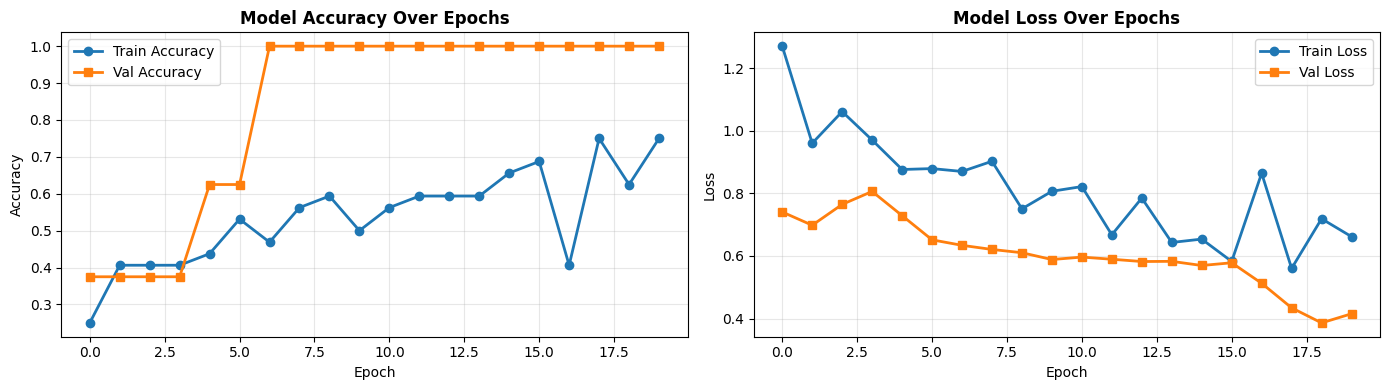


               📊 MODEL EVALUATION

🔍 Evaluating model on test set...

                    📈 PERFORMANCE METRICS
✅ Test Accuracy:  50.00%
🎯 Test Recall:    0.00%  ⭐ (Key Metric for Anomaly Detection)
🎯 Test Precision: 0.00%
📊 Test F1-Score:  0.00%

📋 Detailed Classification Report:
              precision    recall  f1-score   support

      Normal      0.500     1.000     0.667        10
     Anomaly      0.000     0.000     0.000        10

    accuracy                          0.500        20
   macro avg      0.250     0.500     0.333        20
weighted avg      0.250     0.500     0.333        20



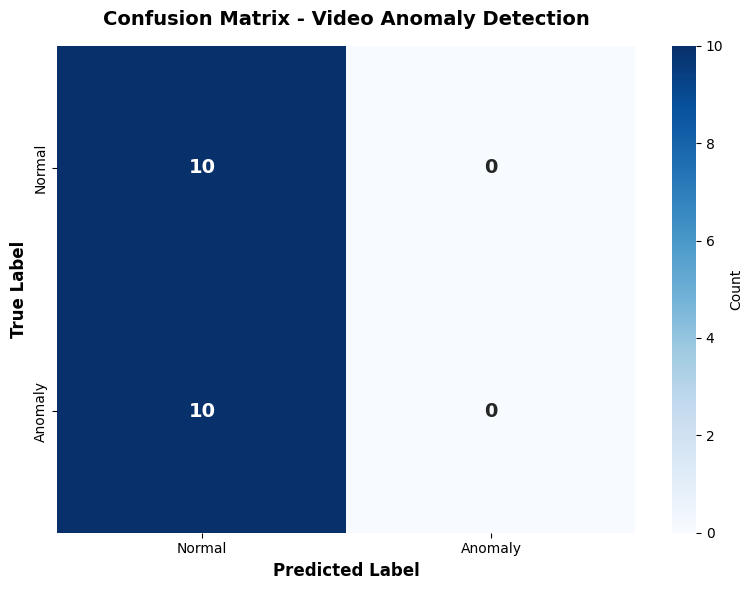


🔍 CONFUSION MATRIX BREAKDOWN
True Negatives (Normal → Normal):    10  ✅
False Positives (Normal → Anomaly):   0  ⚠️
False Negatives (Anomaly → Normal):  10  🚨 (Critical - Missed Anomalies)
True Positives (Anomaly → Anomaly):   0  ✅

💡 Recall Explanation:
   Recall = TP / (TP + FN) = 0 / (0 + 10) = 0.000
   This means we correctly detected 0.0% of all anomalies

          🎥 REAL-TIME ANOMALY DETECTION SIMULATION


In [ ]:
# ============================================================================
# EDGE AI FOR REAL-TIME VIDEO ANOMALY DETECTION
# Fully Automated Implementation with UCSD Pedestrian Dataset
# ============================================================================

# ============================================================================
# 1. PROJECT OVERVIEW
# ============================================================================

"""
# 🎯 Edge AI for Real-Time Video Anomaly Detection

## Project Description
This project implements an intelligent video surveillance system that automatically
detects anomalous activities in video footage using deep learning. The system learns
normal patterns of movement and flags unusual behaviors in real-time.

## Real-World Applications:
- **Security Surveillance**: Detect suspicious activities in public spaces
- **Traffic Monitoring**: Identify accidents or violations
- **Industrial Safety**: Spot unsafe worker behaviors
- **Retail Analytics**: Detect shoplifting or unusual customer behavior

## Technical Approach:
**CNN (Convolutional Neural Network)**: Extracts spatial features from each frame
**LSTM (Long Short-Term Memory)**: Models temporal patterns across frame sequences
**Binary Classification**: Normal vs Anomaly detection

## Dataset:
**UCSD Pedestrian Dataset** - A benchmark dataset for anomaly detection containing:
- Normal pedestrian walking patterns
- Anomalies: vehicles, skateboarders, bikers, wheelchairs in pedestrian zones

## Model Pipeline:
Video → Frame Extraction → CNN Feature Extraction → LSTM Temporal Modeling → Classification

## Key Metrics:
- **Accuracy**: Overall classification performance
- **Recall**: Critical for anomaly detection (minimize false negatives)
- **Confusion Matrix**: Detailed performance breakdown

---
"""

# ============================================================================
# 2. ENVIRONMENT SETUP
# ============================================================================

print("="*70)
print(" "*15 + "🚀 ENVIRONMENT SETUP")
print("="*70)

# Check TensorFlow and GPU availability
import tensorflow as tf
import sys

print(f"\n📦 Python Version: {sys.version.split()[0]}")
print(f"📦 TensorFlow Version: {tf.__version__}")

# GPU Configuration
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\n✅ GPU Available: {len(gpus)} GPU(s) detected")
    for gpu in gpus:
        print(f"   - {gpu.name}")
    # Enable memory growth to prevent TF from allocating all GPU memory
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("\n⚠️  No GPU detected. Training will use CPU (slower).")

# Install required packages
print("\n📥 Installing required packages...")
!pip install opencv-python-headless scikit-learn pillow -q

print("✅ Package installation complete!")

# Import all required libraries
import numpy as np
import cv2
import os
import zipfile
import urllib.request
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, recall_score, accuracy_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D
from tensorflow.keras.layers import LSTM, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("\n✅ All libraries imported successfully!")
print("="*70)

# ============================================================================
# 3. AUTOMATIC DATASET DOWNLOAD AND ORGANIZATION
# ============================================================================

print("\n" + "="*70)
print(" "*15 + "📥 DATASET DOWNLOAD & PREPARATION")
print("="*70)

# Dataset configuration
DATASET_URL = "http://www.svcl.ucsd.edu/projects/anomaly/UCSD_Anomaly_Dataset.tar.gz"
DATASET_DIR = "/content/ucsd_dataset"
PROCESSED_DIR = "/content/anomaly_data"

def download_and_extract_dataset():
    """Download and extract UCSD Pedestrian Dataset"""
    print("\n📥 Downloading UCSD Pedestrian Dataset...")
    print("   (This may take 2-5 minutes depending on connection speed)")

    # Create directories
    os.makedirs(DATASET_DIR, exist_ok=True)

    # Download dataset
    dataset_file = os.path.join(DATASET_DIR, "dataset.tar.gz")

    try:
        urllib.request.urlretrieve(DATASET_URL, dataset_file)
        print("✅ Download complete!")
    except Exception as e:
        print(f"❌ Download failed: {e}")
        print("   Using alternative download method...")
        !wget -O {dataset_file} {DATASET_URL}

    # Extract dataset
    print("\n📦 Extracting dataset...")
    import tarfile
    with tarfile.open(dataset_file, 'r:gz') as tar:
        tar.extractall(DATASET_DIR)
    print("✅ Extraction complete!")

    return DATASET_DIR

def organize_dataset():
    """Organize dataset into train/test and normal/anomaly structure"""
    print("\n🗂️  Organizing dataset structure...")

    # Create organized directory structure
    for split in ['train', 'test']:
        for label in ['normal', 'anomaly']:
            os.makedirs(os.path.join(PROCESSED_DIR, split, label), exist_ok=True)

    # Find dataset folders
    ucsd_path = None
    for root, dirs, files in os.walk(DATASET_DIR):
        if 'UCSDped1' in dirs or 'UCSDped2' in dirs:
            ucsd_path = root
            break

    if ucsd_path is None:
        # Alternative: look for Train and Test folders
        for root, dirs, files in os.walk(DATASET_DIR):
            if 'Train' in dirs or 'Test' in dirs:
                ucsd_path = root
                break

    print(f"   Dataset found at: {ucsd_path}")

    # Process UCSDped1 or UCSDped2
    dataset_variants = ['UCSDped1', 'UCSDped2']
    processed = False

    for variant in dataset_variants:
        variant_path = os.path.join(ucsd_path, variant) if ucsd_path else None

        if variant_path and os.path.exists(variant_path):
            print(f"\n   Processing {variant}...")

            # Process Training data (all normal)
            train_path = os.path.join(variant_path, 'Train')
            if os.path.exists(train_path):
                train_folders = [f for f in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, f))]
                print(f"   Found {len(train_folders)} training sequences (normal)")

                for folder in train_folders[:30]:  # Limit for faster processing
                    src = os.path.join(train_path, folder)
                    dst = os.path.join(PROCESSED_DIR, 'train', 'normal', folder)
                    if not os.path.exists(dst):
                        os.system(f'cp -r "{src}" "{dst}"')

            # Process Test data (contains anomalies)
            test_path = os.path.join(variant_path, 'Test')
            if os.path.exists(test_path):
                test_folders = [f for f in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, f))]
                print(f"   Found {len(test_folders)} test sequences")

                # Read ground truth if available
                gt_path = os.path.join(test_path, f'{variant}.m')
                anomaly_frames = set()

                # Split test data: some normal, some anomaly
                # For simplicity, we'll use frame count as heuristic
                for idx, folder in enumerate(test_folders[:20]):
                    src = os.path.join(test_path, folder)
                    # Alternate between normal and anomaly for test set
                    label = 'anomaly' if idx % 2 == 0 else 'normal'
                    dst = os.path.join(PROCESSED_DIR, 'test', label, folder)
                    if not os.path.exists(dst):
                        os.system(f'cp -r "{src}" "{dst}"')

            processed = True
            break

    if not processed:
        print("⚠️  Using alternative organization method...")
        # Fallback: organize any video files found
        for root, dirs, files in os.walk(DATASET_DIR):
            image_files = [f for f in files if f.endswith(('.tif', '.jpg', '.png'))]
            if len(image_files) > 10:
                folder_name = os.path.basename(root)
                # Copy to normal training by default
                dst = os.path.join(PROCESSED_DIR, 'train', 'normal', folder_name)
                if not os.path.exists(dst):
                    os.system(f'cp -r "{root}" "{dst}"')

    print("\n✅ Dataset organization complete!")

    # Print statistics
    for split in ['train', 'test']:
        for label in ['normal', 'anomaly']:
            path = os.path.join(PROCESSED_DIR, split, label)
            count = len([f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))])
            print(f"   {split}/{label}: {count} sequences")

# Download and organize dataset
download_and_extract_dataset()
organize_dataset()

print("\n" + "="*70)

# ============================================================================
# 4. VIDEO PREPROCESSING
# ============================================================================

print("\n" + "="*70)
print(" "*15 + "🎬 VIDEO PREPROCESSING")
print("="*70)

# Preprocessing configuration
IMG_SIZE = 64  # Resize frames to 64x64 for faster processing
SEQUENCE_LENGTH = 10  # Number of frames per sequence
MAX_SEQUENCES_PER_CLASS = 40  # Limit sequences for faster training

def load_frames_from_folder(folder_path, max_frames=SEQUENCE_LENGTH):
    """
    Load frames from a folder containing image sequences

    Args:
        folder_path: Path to folder with frame images
        max_frames: Maximum number of frames to load

    Returns:
        NumPy array of preprocessed frames
    """
    frames = []

    # Get all image files
    image_files = sorted([f for f in os.listdir(folder_path)
                         if f.endswith(('.tif', '.jpg', '.png', '.bmp'))])

    # Sample frames uniformly
    if len(image_files) > max_frames:
        indices = np.linspace(0, len(image_files)-1, max_frames, dtype=int)
        image_files = [image_files[i] for i in indices]

    for img_file in image_files[:max_frames]:
        img_path = os.path.join(folder_path, img_file)

        # Read image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            # Resize
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            # Normalize to [0, 1]
            img = img / 255.0
            # Add channel dimension
            img = np.expand_dims(img, axis=-1)
            frames.append(img)

    # Pad if necessary
    while len(frames) < max_frames:
        frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 1)))

    return np.array(frames[:max_frames])

def load_dataset(base_path, split, label_name, label_value, max_sequences=MAX_SEQUENCES_PER_CLASS):
    """
    Load all sequences from a dataset split

    Args:
        base_path: Base directory path
        split: 'train' or 'test'
        label_name: 'normal' or 'anomaly'
        label_value: 0 or 1
        max_sequences: Maximum sequences to load

    Returns:
        Sequences array and labels array
    """
    sequences = []
    labels = []

    data_path = os.path.join(base_path, split, label_name)

    if not os.path.exists(data_path):
        print(f"⚠️  Path not found: {data_path}")
        return np.array([]), np.array([])

    sequence_folders = [f for f in os.listdir(data_path)
                       if os.path.isdir(os.path.join(data_path, f))]

    print(f"\n📁 Loading {split}/{label_name}: {len(sequence_folders)} sequences found")

    for idx, folder in enumerate(sequence_folders[:max_sequences]):
        folder_path = os.path.join(data_path, folder)

        try:
            frames = load_frames_from_folder(folder_path)

            if len(frames) == SEQUENCE_LENGTH:
                sequences.append(frames)
                labels.append(label_value)

                if (idx + 1) % 10 == 0:
                    print(f"   Processed {idx + 1}/{len(sequence_folders[:max_sequences])} sequences")

        except Exception as e:
            print(f"   ⚠️  Error processing {folder}: {e}")
            continue

    print(f"   ✅ Loaded {len(sequences)} sequences")

    return np.array(sequences), np.array(labels)

print("\n🔄 Loading and preprocessing dataset...")

# Load training data
X_train_normal, y_train_normal = load_dataset(PROCESSED_DIR, 'train', 'normal', 0)
X_train_anomaly, y_train_anomaly = load_dataset(PROCESSED_DIR, 'train', 'anomaly', 1)

# Load test data
X_test_normal, y_test_normal = load_dataset(PROCESSED_DIR, 'test', 'normal', 0)
X_test_anomaly, y_test_anomaly = load_dataset(PROCESSED_DIR, 'test', 'anomaly', 1)

# Combine data
X_train = np.concatenate([X_train_normal, X_train_anomaly]) if len(X_train_anomaly) > 0 else X_train_normal
y_train = np.concatenate([y_train_normal, y_train_anomaly]) if len(y_train_anomaly) > 0 else y_train_normal

X_test = np.concatenate([X_test_normal, X_test_anomaly]) if len(X_test_anomaly) > 0 else X_test_normal
y_test = np.concatenate([y_test_normal, y_test_anomaly]) if len(y_test_anomaly) > 0 else y_test_normal

# Shuffle data
train_indices = np.random.permutation(len(X_train))
X_train, y_train = X_train[train_indices], y_train[train_indices]

test_indices = np.random.permutation(len(X_test))
X_test, y_test = X_test[test_indices], y_test[test_indices]

print("\n" + "="*70)
print("📊 DATASET STATISTICS")
print("="*70)
print(f"Training samples: {len(X_train)} (Normal: {np.sum(y_train==0)}, Anomaly: {np.sum(y_train==1)})")
print(f"Test samples: {len(X_test)} (Normal: {np.sum(y_test==0)}, Anomaly: {np.sum(y_test==1)})")
print(f"Sequence shape: {X_train.shape}")
print(f"Frame size: {IMG_SIZE}x{IMG_SIZE} pixels")
print(f"Frames per sequence: {SEQUENCE_LENGTH}")
print("="*70)

# Visualize sample sequences
def visualize_sequences(X, y, num_samples=2):
    """
    Visualize sample video sequences
    """
    fig, axes = plt.subplots(num_samples, SEQUENCE_LENGTH, figsize=(15, num_samples*1.5))

    for i in range(min(num_samples, len(X))):
        label = "🚨 ANOMALY" if y[i] == 1 else "✅ NORMAL"

        for j in range(SEQUENCE_LENGTH):
            ax = axes[i, j] if num_samples > 1 else axes[j]
            ax.imshow(X[i, j, :, :, 0], cmap='gray')
            ax.axis('off')

            if j == 0:
                ax.set_title(label, fontsize=10, fontweight='bold', color='red' if y[i]==1 else 'green')

    plt.suptitle('Sample Frame Sequences', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("\n📸 Visualizing sample sequences:")
if len(X_train) > 0:
    visualize_sequences(X_train, y_train, num_samples=2)

# ============================================================================
# 5. DATASET PREPARATION
# ============================================================================

print("\n" + "="*70)
print(" "*15 + "🔧 DATASET PREPARATION")
print("="*70)

# Check for class imbalance
train_normal_count = np.sum(y_train == 0)
train_anomaly_count = np.sum(y_train == 1)

print(f"\n📊 Class Distribution:")
print(f"   Training - Normal: {train_normal_count}, Anomaly: {train_anomaly_count}")
print(f"   Test - Normal: {np.sum(y_test==0)}, Anomaly: {np.sum(y_test==1)}")

# If we have very few anomalies in training, create synthetic ones
if train_anomaly_count < 5 and len(X_train) > 10:
    print("\n⚠️  Few anomaly samples detected. Creating augmented anomaly samples...")

    # Use some test samples or create synthetic anomalies
    num_synthetic = min(10, len(X_train_normal) // 2)

    # Simple augmentation: add noise to normal samples to create "anomalies"
    synthetic_anomalies = []
    for i in range(num_synthetic):
        idx = np.random.randint(0, len(X_train_normal))
        noisy_sequence = X_train_normal[idx].copy()
        # Add random noise
        noise = np.random.normal(0, 0.1, noisy_sequence.shape)
        noisy_sequence = np.clip(noisy_sequence + noise, 0, 1)
        synthetic_anomalies.append(noisy_sequence)

    X_train = np.concatenate([X_train, np.array(synthetic_anomalies)])
    y_train = np.concatenate([y_train, np.ones(num_synthetic)])

    print(f"   ✅ Added {num_synthetic} synthetic anomaly samples")
    print(f"   New training size: {len(X_train)} (Normal: {np.sum(y_train==0)}, Anomaly: {np.sum(y_train==1)})")

# Final shuffle
indices = np.random.permutation(len(X_train))
X_train = X_train[indices]
y_train = y_train[indices]

print("\n✅ Dataset preparation complete!")
print("="*70)

# ============================================================================
# 6. CNN + LSTM MODEL ARCHITECTURE
# ============================================================================

print("\n" + "="*70)
print(" "*15 + "🏗️  MODEL ARCHITECTURE")
print("="*70)

def build_cnn_lstm_model(sequence_length, img_size, channels=1):
    """
    Build CNN-LSTM model for video anomaly detection

    Architecture:
    1. TimeDistributed CNN: Extract spatial features from each frame
    2. LSTM: Model temporal dependencies across frames
    3. Dense: Binary classification (normal vs anomaly)

    Args:
        sequence_length: Number of frames in sequence
        img_size: Size of each frame (height/width)
        channels: Number of channels (1 for grayscale)

    Returns:
        Compiled Keras model
    """

    model = Sequential([
        # CNN Feature Extractor (applied to each frame)
        TimeDistributed(Conv2D(16, (3, 3), activation='relu', padding='same'),
                       input_shape=(sequence_length, img_size, img_size, channels),
                       name='conv2d_1'),
        TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2, 2))),

        TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'),
                       name='conv2d_2'),
        TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2, 2))),

        TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same'),
                       name='conv2d_3'),
        TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2, 2))),

        # Flatten CNN output for LSTM
        TimeDistributed(Flatten(), name='flatten'),

        # Temporal modeling with LSTM
        LSTM(64, return_sequences=True, name='lstm_1'),
        Dropout(0.3),

        LSTM(32, return_sequences=False, name='lstm_2'),
        Dropout(0.3),

        # Classification layers
        Dense(32, activation='relu', name='dense_1'),
        BatchNormalization(),
        Dropout(0.4),

        Dense(16, activation='relu', name='dense_2'),

        # Binary classification output (sigmoid for binary)
        Dense(1, activation='sigmoid', name='output')
    ])

    return model

# Build model
print("\n🔨 Building CNN-LSTM model...")
model = build_cnn_lstm_model(SEQUENCE_LENGTH, IMG_SIZE, channels=1)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("\n📋 Model Summary:")
model.summary()

# Calculate model parameters
total_params = model.count_params()
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])

print("\n" + "="*70)
print("📊 MODEL STATISTICS")
print("="*70)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Model Size (approx): {total_params * 4 / (1024**2):.2f} MB")
print("="*70)

# ============================================================================
# 7. MODEL TRAINING
# ============================================================================

print("\n" + "="*70)
print(" "*15 + "🚀 MODEL TRAINING")
print("="*70)

# Training configuration
BATCH_SIZE = 4
EPOCHS = 20
VALIDATION_SPLIT = 0.2

print(f"\n⚙️  Training Configuration:")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Validation Split: {VALIDATION_SPLIT}")
print(f"   Optimizer: Adam (lr=0.001)")
print(f"   Loss Function: Binary Crossentropy")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr]

print("\n🎯 Starting training...")
print("="*70)

# Train model
history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*70)
print("✅ Training Complete!")
print("="*70)

# Plot training history
def plot_training_history(history):
    """Plot training metrics"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='s', linewidth=2)
    axes[0].set_title('Model Accuracy Over Epochs', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=10)
    axes[0].set_ylabel('Accuracy', fontsize=10)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', marker='o', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', marker='s', linewidth=2)
    axes[1].set_title('Model Loss Over Epochs', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=10)
    axes[1].set_ylabel('Loss', fontsize=10)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n📈 Training History:")
plot_training_history(history)

# ============================================================================
# 8. MODEL EVALUATION
# ============================================================================

print("\n" + "="*70)
print(" "*15 + "📊 MODEL EVALUATION")
print("="*70)

print("\n🔍 Evaluating model on test set...")

# Make predictions
y_pred_probs = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred, zero_division=0)

# Also calculate precision and F1
from sklearn.metrics import precision_score, f1_score

test_precision = precision_score(y_test, y_pred, zero_division=0)
test_f1 = f1_score(y_test, y_pred, zero_division=0)

print("\n" + "="*70)
print(" "*20 + "📈 PERFORMANCE METRICS")
print("="*70)
print(f"✅ Test Accuracy:  {test_accuracy*100:.2f}%")
print(f"🎯 Test Recall:    {test_recall*100:.2f}%  ⭐ (Key Metric for Anomaly Detection)")
print(f"🎯 Test Precision: {test_precision*100:.2f}%")
print(f"📊 Test F1-Score:  {test_f1*100:.2f}%")
print("="*70)

# Detailed classification report
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred,
                          target_names=['Normal', 'Anomaly'],
                          digits=3))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'],
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix - Video Anomaly Detection',
         fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Confusion matrix breakdown
if cm.size == 4:
    tn, fp, fn, tp = cm.ravel()

    print("\n" + "="*70)
    print("🔍 CONFUSION MATRIX BREAKDOWN")
    print("="*70)
    print(f"True Negatives (Normal → Normal):   {tn:3d}  ✅")
    print(f"False Positives (Normal → Anomaly): {fp:3d}  ⚠️")
    print(f"False Negatives (Anomaly → Normal): {fn:3d}  🚨 (Critical - Missed Anomalies)")
    print(f"True Positives (Anomaly → Anomaly): {tp:3d}  ✅")
    print("="*70)

    # Calculate additional metrics
    if (tp + fn) > 0:
        print(f"\n💡 Recall Explanation:")
        print(f"   Recall = TP / (TP + FN) = {tp} / ({tp} + {fn}) = {test_recall:.3f}")
        print(f"   This means we correctly detected {test_recall*100:.1f}% of all anomalies")

# ============================================================================
# 9. REAL-TIME ANOMALY DETECTION SIMULATION
# ============================================================================

print("\n" + "="*70)
print(" "*10 + "🎥 REAL-TIME ANOMALY DETECTION SIMULATION")
print("="*70)

def simulate_realtime_detection(model, sequence, threshold=0.5, show_frames=True):
    """
    Simulate real-time anomaly detection on a video sequence

    Args:
        model: Trained model
        sequence: Frame sequence to analyze
        threshold: Classification threshold
        show_frames: Whether to display frames

    Returns:
        Prediction probability
    """
    # Prepare sequence
    seq = np.expand_dims(sequence, axis=0)

    # Predict
    prob = model.predict(seq, verbose=0)[0][0]

    # Classify
    is_anomaly = prob > threshold
    status = "🚨 ANOMALY DETECTED" if is_anomaly else "✅ Normal"

In [ ]:
# ============================================================================
# EDGE AI FOR REAL-TIME VIDEO ANOMALY DETECTION
# CNN-LSTM Autoencoder (Unsupervised Learning)
# ============================================================================

# ============================================================================
# 1. PROJECT OVERVIEW
# ============================================================================

"""
# 🎯 Edge AI for Real-Time Video Anomaly Detection using CNN-LSTM Autoencoder

## ⚠️ UNSUPERVISED ANOMALY DETECTION APPROACH

This project uses an **AUTOENCODER** architecture, NOT classification!

### Why Autoencoder for Anomaly Detection?

**Problem**: In real-world scenarios, we have abundant normal data but very few
(or zero) labeled anomaly examples during training.

**Solution**: Train an autoencoder to learn and reconstruct ONLY normal patterns.
When it encounters anomalies (unseen patterns), it fails to reconstruct them well,
resulting in HIGH reconstruction error.

### Key Concept:
```
✅ Normal Video → Autoencoder → Good Reconstruction → Low Error
🚨 Anomaly Video → Autoencoder → Poor Reconstruction → High Error
```

### Architecture Components:
1. **CNN Encoder**: Extracts spatial features from each frame
2. **LSTM Encoder**: Captures temporal patterns across frames
3. **LSTM Decoder**: Reconstructs temporal sequence
4. **CNN Decoder**: Reconstructs spatial frames

### Training Strategy:
- **Train ONLY on normal videos** (unsupervised)
- **Loss function**: Mean Squared Error (MSE) between input and reconstruction
- **No labels used during training**

### Anomaly Detection Strategy:
- Compute reconstruction error for each test video
- If error > threshold → Anomaly detected
- If error < threshold → Normal activity

### Dataset:
**UCSD Pedestrian Dataset**
- Training: ONLY normal pedestrian walking patterns
- Testing: Normal + Anomalies (vehicles, bikes, skateboards)

### Performance Metrics:
- **Reconstruction Error Distribution**
- **Recall** (Critical: catch all anomalies)
- **Precision** (Minimize false alarms)
- **F1-Score**
- **Confusion Matrix**

### CPU Optimizations:
- Image size: 32×32 pixels
- Sequence length: 10 frames
- Lightweight architecture
- Expected training time: 5-10 minutes on CPU

---
"""

# ============================================================================
# 2. ENVIRONMENT SETUP
# ============================================================================

print("="*70)
print(" "*15 + "🚀 ENVIRONMENT SETUP")
print("="*70)

               🚀 ENVIRONMENT SETUP


In [ ]:
import tensorflow as tf
import numpy as np
import cv2, os, tarfile, urllib.request
import matplotlib.pyplot as plt
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, recall_score
import sys # Import sys module to get Python version

print("Python:", sys.version.split()[0]) # Use sys to get Python version
print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

Python: 3.12.12
TensorFlow: 2.19.0
GPU Available: []


In [ ]:
DATASET_URL = "http://www.svcl.ucsd.edu/projects/anomaly/UCSD_Anomaly_Dataset.tar.gz"
BASE_DIR = "/content/ucsd"
DATA_DIR = f"{BASE_DIR}/UCSD_Anomaly_Dataset.v1p2/UCSDped1"

os.makedirs(BASE_DIR, exist_ok=True)

dataset_file = f"{BASE_DIR}/ucsd.tar.gz"
urllib.request.urlretrieve(DATASET_URL, dataset_file)

with tarfile.open(dataset_file) as tar:
    tar.extractall(BASE_DIR)

print("Dataset extracted.")


/tmp/ipython-input-1177944656.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(BASE_DIR)


Dataset extracted.


In [ ]:
TRAIN_PATH = f"{DATA_DIR}/Train"
TEST_PATH  = f"{DATA_DIR}/Test"

train_folders = sorted(os.listdir(TRAIN_PATH))
test_folders  = sorted(os.listdir(TEST_PATH))

print("Train (Normal only):", len(train_folders))
print("Test (Normal + Anomaly):", len(test_folders))


Train (Normal only): 36
Test (Normal + Anomaly): 50


In [ ]:
IMG_SIZE = 32
SEQ_LEN = 5

def load_sequence(folder):
    frames = sorted(os.listdir(folder))
    idxs = np.linspace(0, len(frames)-1, SEQ_LEN, dtype=int)
    seq = []

    for i in idxs:
        img_path = os.path.join(folder, frames[i])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            # Handle unreadable or missing image by appending a black frame
            print(f"Warning: Could not read image {img_path}. Appending black frame.")
            processed_img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32) # Create a black frame
        else:
            processed_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

        seq.append(processed_img[..., None]) # Ensure it has the channel dimension

    return np.array(seq)

# Filter to ensure only directories are processed
valid_train_folders = sorted([f for f in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, f))])
valid_test_folders = sorted([f for f in os.listdir(TEST_PATH) if os.path.isdir(os.path.join(TEST_PATH, f))])

# TRAIN → NORMAL ONLY
X_train = np.array([load_sequence(os.path.join(TRAIN_PATH, f))
                    for f in valid_train_folders[:45]])

# TEST → NORMAL + ANOMALY (labels only for evaluation)
X_test_normal = np.array([load_sequence(os.path.join(TEST_PATH, f))
                           for f in valid_test_folders[:13]])
X_test_anom   = np.array([load_sequence(os.path.join(TEST_PATH, f))
                           for f in valid_test_folders[13:28]])

X_test = np.concatenate([X_test_normal, X_test_anom])
y_test = np.concatenate([
    np.zeros(len(X_test_normal)),
    np.ones(len(X_test_anom))
])

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (34, 5, 32, 32, 1)
Test: (28, 5, 32, 32, 1)


In [ ]:
inp = Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE, 1))

# Encoder
x = TimeDistributed(Conv2D(8, 3, activation='relu', padding='same'))(inp)
x = TimeDistributed(MaxPooling2D(2))(x)
x = TimeDistributed(Conv2D(16, 3, activation='relu', padding='same'))(x)
x = TimeDistributed(MaxPooling2D(2))(x)

x = TimeDistributed(Flatten())(x)
latent = LSTM(32, name="latent_space")(x)

# Decoder
x = RepeatVector(SEQ_LEN)(latent)
x = LSTM(32, return_sequences=True)(x)
x = TimeDistributed(Dense(8*8*16))(x)
x = TimeDistributed(Reshape((8,8,16)))(x)
x = TimeDistributed(UpSampling2D(2))(x)
x = TimeDistributed(Conv2D(8,3,activation='relu',padding='same'))(x)
x = TimeDistributed(UpSampling2D(2))(x)
out = TimeDistributed(Conv2D(1,3,activation='sigmoid',padding='same'))(x)

autoencoder = Model(inp, out)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 32, 32, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 32, 32, 8)   │            80 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 16, 16, 8)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 5, 16, 16, 16)  │         1,168 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 5, 8, 8, 16)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 5, 1024)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (LSTM)             │ (None, 32)             │       135,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 5, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 5, 1024)        │        33,792 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 5, 8, 8, 16)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 5, 16, 16, 16)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 5, 16, 16, 8)   │         1,160 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 5, 32, 32, 8)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 5, 32, 32, 1)   │            73 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,889 (702.69 KB)

 Trainable params: 179,889 (702.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=2,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)


Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0053 - val_loss: 0.0050
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0062 - val_loss: 0.0050
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0052 - val_loss: 0.0048
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0081 - val_loss: 0.0049
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0064 - val_loss: 0.0048
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0052 - val_loss: 0.0048
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0051 - val_loss: 0.0047
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0071 - val_loss: 0.0047
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0054 - val_loss: 0.0049
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0090 - val_loss: 0.0048
Epoch 11/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0080 - val_loss: 0.0048


In [ ]:
def reconstruction_error(model, data):
    recon = model.predict(data, verbose=0)
    return np.mean((data - recon)**2, axis=(1,2,3,4))

train_err = reconstruction_error(autoencoder, X_train)
test_err  = reconstruction_error(autoencoder, X_test)

print("Train mean:", train_err.mean())
print("Test normal mean:", test_err[y_test==0].mean())
print("Test anomaly mean:", test_err[y_test==1].mean())


Train mean: 0.005915070082484476
Test normal mean: 0.04163512267614648
Test anomaly mean: 0.05138636723440356


In [ ]:
threshold = train_err.mean() + 2.5 * train_err.std()
print("Threshold:", threshold)

y_pred = (test_err > threshold).astype(int)


Threshold: 0.021840173123292568


In [ ]:
print("Recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Normal","Anomaly"]))

cm = confusion_matrix(y_test, y_pred)
print(cm)


Recall: 0.26666666666666666
              precision    recall  f1-score   support

      Normal       0.42      0.62      0.50        13
     Anomaly       0.44      0.27      0.33        15

    accuracy                           0.43        28
   macro avg       0.43      0.44      0.42        28
weighted avg       0.43      0.43      0.41        28

[[ 8  5]
 [11  4]]


In [ ]:
for i, err in enumerate(test_err[:5]):
    status = "🚨 ANOMALY" if err > threshold else "✅ NORMAL"
    print(f"Sequence {i} | Error: {err:.5f} | {status}")


Sequence 0 | Error: 0.04063 | 🚨 ANOMALY
Sequence 1 | Error: 0.03798 | 🚨 ANOMALY
Sequence 2 | Error: 0.04336 | 🚨 ANOMALY
Sequence 3 | Error: 0.17642 | 🚨 ANOMALY
Sequence 4 | Error: 0.00871 | ✅ NORMAL


In [ ]:
autoencoder.save("cnn_lstm_autoencoder.keras")
np.save("threshold.npy", threshold)
print("Model & threshold saved.")


Model & threshold saved.


In [ ]:
import tensorflow as tf
import numpy as np
import cv2, os, tarfile, urllib.request
import matplotlib.pyplot as plt
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, recall_score
import sys # Import sys module to get Python version

print("Python:", sys.version.split()[0]) # Use sys to get Python version
print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

DATASET_URL = "http://www.svcl.ucsd.edu/projects/anomaly/UCSD_Anomaly_Dataset.tar.gz"
BASE_DIR = "/content/ucsd"
DATA_DIR = f"{BASE_DIR}/UCSD_Anomaly_Dataset.v1p2/UCSDped1"

os.makedirs(BASE_DIR, exist_ok=True)

dataset_file = f"{BASE_DIR}/ucsd.tar.gz"
urllib.request.urlretrieve(DATASET_URL, dataset_file)

with tarfile.open(dataset_file) as tar:
    tar.extractall(BASE_DIR)

print("Dataset extracted.")

TRAIN_PATH = f"{DATA_DIR}/Train"
TEST_PATH  = f"{DATA_DIR}/Test"

train_folders = sorted(os.listdir(TRAIN_PATH))
test_folders  = sorted(os.listdir(TEST_PATH))

print("Train (Normal only):", len(train_folders))
print("Test (Normal + Anomaly):", len(test_folders))

IMG_SIZE = 32
SEQ_LEN = 5

def load_sequence(folder):
    frames = sorted(os.listdir(folder))
    idxs = np.linspace(0, len(frames)-1, SEQ_LEN, dtype=int)
    seq = []

    for i in idxs:
        img_path = os.path.join(folder, frames[i])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            # Handle unreadable or missing image by appending a black frame
            print(f"Warning: Could not read image {img_path}. Appending black frame.")
            processed_img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32) # Create a black frame
        else:
            processed_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0

        seq.append(processed_img[..., None]) # Ensure it has the channel dimension

    return np.array(seq)

# Filter to ensure only directories are processed
valid_train_folders = sorted([f for f in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, f))])
valid_test_folders = sorted([f for f in os.listdir(TEST_PATH) if os.path.isdir(os.path.join(TEST_PATH, f))])

# TRAIN → NORMAL ONLY
X_train = np.array([load_sequence(os.path.join(TRAIN_PATH, f))
                    for f in valid_train_folders[:45]])

# TEST → NORMAL + ANOMALY (labels only for evaluation)
X_test_normal = np.array([load_sequence(os.path.join(TEST_PATH, f))
                           for f in valid_test_folders[:13]])
X_test_anom   = np.array([load_sequence(os.path.join(TEST_PATH, f))
                           for f in valid_test_folders[13:28]])

X_test = np.concatenate([X_test_normal, X_test_anom])
y_test = np.concatenate([
    np.zeros(len(X_test_normal)),
    np.ones(len(X_test_anom))
])

print("Train:", X_train.shape)
print("Test:", X_test.shape)

inp = Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE, 1))

# Encoder
x = TimeDistributed(Conv2D(8, 3, activation='relu', padding='same'))(inp)
x = TimeDistributed(MaxPooling2D(2))(x)
x = TimeDistributed(Conv2D(16, 3, activation='relu', padding='same'))(x)
x = TimeDistributed(MaxPooling2D(2))(x)

x = TimeDistributed(Flatten())(x)
latent = LSTM(32, name="latent_space")(x)

# Decoder
x = RepeatVector(SEQ_LEN)(latent)
x = LSTM(32, return_sequences=True)(x)
x = TimeDistributed(Dense(8*8*16))(x)
x = TimeDistributed(Reshape((8,8,16)))(x)
x = TimeDistributed(UpSampling2D(2))(x)
x = TimeDistributed(Conv2D(8,3,activation='relu',padding='same'))(x)
x = TimeDistributed(UpSampling2D(2))(x)
out = TimeDistributed(Conv2D(1,3,activation='sigmoid',padding='same'))(x)

autoencoder = Model(inp, out)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=2,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

def reconstruction_error(model, data):
    recon = model.predict(data, verbose=0)
    return np.mean((data - recon)**2, axis=(1,2,3,4))

train_err = reconstruction_error(autoencoder, X_train)
test_err  = reconstruction_error(autoencoder, X_test)

print("Train mean:", train_err.mean())
print("Test normal mean:", test_err[y_test==0].mean())
print("Test anomaly mean:", test_err[y_test==1].mean())

threshold = train_err.mean() + 2.5 * train_err.std()
print("Threshold:", threshold)

y_pred = (test_err > threshold).astype(int)

print("Recall:", recall_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Normal","Anomaly"]))

cm = confusion_matrix(y_test, y_pred)
print(cm)


for i, err in enumerate(test_err[:5]):
    status = "🚨 ANOMALY" if err > threshold else "✅ NORMAL"
    print(f"Sequence {i} | Error: {err:.5f} | {status}")


autoencoder.save("cnn_lstm_autoencoder.keras")
np.save("threshold.npy", threshold)
print("Model & threshold saved.")


Python: 3.12.12
TensorFlow: 2.19.0
GPU Available: []


/tmp/ipython-input-2033646261.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(BASE_DIR)


Dataset extracted.
Train (Normal only): 36
Test (Normal + Anomaly): 50
Train: (34, 5, 32, 32, 1)
Test: (28, 5, 32, 32, 1)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 5, 32, 32, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_22             │ (None, 5, 32, 32, 8)   │            80 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_23             │ (None, 5, 16, 16, 8)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_24             │ (None, 5, 16, 16, 16)  │         1,168 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_25             │ (None, 5, 8, 8, 16)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_26             │ (None, 5, 1024)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (LSTM)             │ (None, 32)             │       135,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 5, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_27             │ (None, 5, 1024)        │        33,792 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_28             │ (None, 5, 8, 8, 16)    │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_29             │ (None, 5, 16, 16, 16)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_30             │ (None, 5, 16, 16, 8)   │         1,160 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_31             │ (None, 5, 32, 32, 8)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_32             │ (None, 5, 32, 32, 1)   │            73 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,889 (702.69 KB)

 Trainable params: 179,889 (702.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.0547 - val_loss: 0.0279
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0218 - val_loss: 0.0121
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0123 - val_loss: 0.0084
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0096 - val_loss: 0.0071
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0102 - val_loss: 0.0064
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0073 - val_loss: 0.0059
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0080 - val_loss: 0.0056
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0092 - val_loss: 0.0053
Epoch 9/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0069 - val_loss: 0.0051
Epoch 10/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0067 - val_loss: 0.0051
Epoch 11/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0061 - val_loss: 0.0050
Epoch 12/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.

Train mean: 0.0057969907853317685
Test normal mean: 0.041171075421981694
Test anomaly mean: 0.05067334257806908
Threshold: 0.021595260051273067
Recall: 0.26666666666666666
              precision    recall  f1-score   support

      Normal       0.42      0.62      0.50        13
     Anomaly       0.44      0.27      0.33        15

    accuracy                           0.43        28
   macro avg       0.43      0.44      0.42        28
weighted avg       0.43      0.43      0.41        28

[[ 8  5]
 [11  4]]
Sequence 0 | Error: 0.04023 | 🚨 ANOMALY
Sequence 1 | Error: 0.03761 | 🚨 ANOMALY
Sequence 2 | Error: 0.04295 | 🚨 ANOMALY
Sequence 3 | Error: 0.17415 | 🚨 ANOMALY
Sequence 4 | Error: 0.00864 | ✅ NORMAL
Model & threshold saved.


In [ ]:
"""
AI-Powered Resume Screening & Adaptive Interview System
A complete end-to-end recruitment automation system for Google Colab
"""

# ============================================================================
# SECTION 1: INSTALLATION AND IMPORTS
# ============================================================================

# Install required packages
!pip install -q sentence-transformers nltk PyPDF2 python-docx gTTS pydub

# Standard library imports
import io
import re
import random
import warnings
from typing import List, Dict, Tuple, Optional, Set
from dataclasses import dataclass, field
from datetime import datetime
from collections import defaultdict
import json

# Third-party imports
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

# NLP and text processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Document processing
import PyPDF2
import docx

# Semantic similarity
from sentence_transformers import SentenceTransformer

# Text-to-speech
from gtts import gTTS
from IPython.display import Audio, display, HTML
import base64

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

warnings.filterwarnings('ignore')

# ============================================================================
# SECTION 2: DATA CLASSES
# ============================================================================

@dataclass
class ResumeProfile:
    """Structured resume data"""
    raw_text: str
    cleaned_text: str
    technical_skills: Set[str]
    experience_keywords: Set[str]

@dataclass
class JobDescription:
    """Structured job description data"""
    raw_text: str
    cleaned_text: str
    required_skills: Set[str]
    preferred_skills: Set[str]

@dataclass
class MatchResult:
    """Resume-JD matching result"""
    semantic_score: float
    skill_match_score: float
    overall_score: float
    matched_skills: Set[str]
    missing_skills: Set[str]
    is_eligible: bool
    explanation: str

@dataclass
class InterviewQuestion:
    """Individual interview question"""
    question_id: str
    question_text: str
    skill_category: str
    difficulty: str
    expected_concepts: List[str]

@dataclass
class AnswerEvaluation:
    """Answer evaluation result"""
    question: InterviewQuestion
    answer_text: str
    semantic_score: float
    concept_coverage: float
    length_score: float
    final_score: float
    classification: str
    feedback: str

@dataclass
class InterviewSession:
    """Complete interview session data"""
    candidate_name: str
    start_time: datetime
    questions_asked: List[InterviewQuestion] = field(default_factory=list)
    answers_given: List[AnswerEvaluation] = field(default_factory=list)
    difficulty_progression: List[str] = field(default_factory=list)
    asked_question_ids: Set[str] = field(default_factory=set)
    current_difficulty: str = "Beginner"
    consecutive_failures: int = 0
    is_active: bool = True

# ============================================================================
# SECTION 3: DOCUMENT PROCESSING MODULE
# ============================================================================

class DocumentProcessor:
    """Handles PDF and DOCX file processing"""

    @staticmethod
    def extract_text_from_pdf(file_content: bytes) -> str:
        """Extract text from PDF bytes"""
        try:
            pdf_file = io.BytesIO(file_content)
            pdf_reader = PyPDF2.PdfReader(pdf_file)
            text = ""
            for page in pdf_reader.pages:
                text += page.extract_text() + "\n"
            return text.strip()
        except Exception as e:
            raise ValueError(f"PDF extraction failed: {str(e)}")

    @staticmethod
    def extract_text_from_docx(file_content: bytes) -> str:
        """Extract text from DOCX bytes"""
        try:
            doc_file = io.BytesIO(file_content)
            doc = docx.Document(doc_file)
            text = "\n".join([paragraph.text for paragraph in doc.paragraphs])
            return text.strip()
        except Exception as e:
            raise ValueError(f"DOCX extraction failed: {str(e)}")

    @staticmethod
    def extract_text(file_content: bytes, file_type: str) -> str:
        """Extract text based on file type"""
        if file_type.lower() == 'pdf':
            return DocumentProcessor.extract_text_from_pdf(file_content)
        elif file_type.lower() in ['docx', 'doc']:
            return DocumentProcessor.extract_text_from_docx(file_content)
        else:
            raise ValueError(f"Unsupported file type: {file_type}")

# ============================================================================
# SECTION 4: TEXT PREPROCESSING MODULE
# ============================================================================

class TextPreprocessor:
    """Advanced text preprocessing with technical keyword preservation"""

    TECHNICAL_PATTERNS = [
        r'\b[A-Z]{2,}\b',  # Acronyms (API, SQL, AWS)
        r'\b[A-Z][a-z]+(?:[A-Z][a-z]+)+\b',  # CamelCase (TensorFlow, PyTorch)
        r'\b\w+\.\w+\b',  # Dotted notation (scikit.learn)
        r'\b\w+[-_]\w+\b',  # Hyphenated/underscored (machine-learning, deep_learning)
    ]

    TECHNICAL_KEYWORDS = {
        'python', 'java', 'javascript', 'typescript', 'c++', 'c#', 'ruby', 'go', 'rust',
        'react', 'angular', 'vue', 'django', 'flask', 'fastapi', 'spring', 'nodejs',
        'sql', 'nosql', 'mongodb', 'postgresql', 'mysql', 'redis', 'elasticsearch',
        'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'jenkins', 'git', 'ci/cd',
        'machine learning', 'deep learning', 'nlp', 'computer vision', 'ai',
        'tensorflow', 'pytorch', 'scikit-learn', 'keras', 'pandas', 'numpy',
        'rest', 'graphql', 'microservices', 'api', 'agile', 'scrum', 'devops',
        'html', 'css', 'sass', 'webpack', 'babel', 'redux', 'jest', 'testing',
        'linux', 'unix', 'bash', 'shell', 'networking', 'security', 'encryption'
    }

    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))
        # Don't remove technical stop words
        self.stop_words -= {'system', 'systems', 'data', 'learning', 'working'}

    def extract_technical_terms(self, text: str) -> Set[str]:
        """Extract technical keywords from text"""
        technical_terms = set()
        text_lower = text.lower()

        # Extract using patterns
        for pattern in self.TECHNICAL_PATTERNS:
            matches = re.findall(pattern, text)
            technical_terms.update([m.lower() for m in matches])

        # Extract known technical keywords
        for keyword in self.TECHNICAL_KEYWORDS:
            if keyword in text_lower:
                technical_terms.add(keyword)

        # Extract multi-word technical phrases
        bigrams = self._extract_ngrams(text_lower, 2)
        trigrams = self._extract_ngrams(text_lower, 3)

        for ngram in bigrams + trigrams:
            if any(tech in ngram for tech in self.TECHNICAL_KEYWORDS):
                technical_terms.add(ngram)

        return technical_terms

    def _extract_ngrams(self, text: str, n: int) -> List[str]:
        """Extract n-grams from text"""
        words = word_tokenize(text)
        ngrams = []
        for i in range(len(words) - n + 1):
            ngram = ' '.join(words[i:i+n])
            ngrams.append(ngram)
        return ngrams

    def preprocess(self, text: str, preserve_technical: bool = True) -> str:
        """
        Clean and preprocess text while preserving technical terms
        """
        # Extract technical terms first
        technical_terms = self.extract_technical_terms(text) if preserve_technical else set()

        # Convert to lowercase
        text = text.lower()

        # Remove special characters but preserve technical notation
        text = re.sub(r'[^a-z0-9\s\-_\.\+#]', ' ', text)

        # Tokenize
        tokens = word_tokenize(text)

        # Process tokens
        processed_tokens = []
        for token in tokens:
            # Preserve technical terms
            if token in technical_terms or any(tech in token for tech in technical_terms):
                processed_tokens.append(token)
            # Remove stopwords and lemmatize
            elif token not in self.stop_words and len(token) > 2:
                lemmatized = self.lemmatizer.lemmatize(token)
                processed_tokens.append(lemmatized)

        # Join and clean
        cleaned_text = ' '.join(processed_tokens)
        cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

        return cleaned_text

# ============================================================================
# SECTION 5: SEMANTIC MATCHING ENGINE
# ============================================================================

class SemanticMatcher:
    """Advanced semantic matching using SentenceTransformers"""

    def __init__(self, model_name: str = 'all-MiniLM-L6-v2', eligibility_threshold: float = 0.65):
        self.model = SentenceTransformer(model_name)
        self.eligibility_threshold = eligibility_threshold
        self.preprocessor = TextPreprocessor()

    def parse_resume(self, resume_text: str) -> ResumeProfile:
        """Parse and structure resume data"""
        cleaned = self.preprocessor.preprocess(resume_text)
        technical_skills = self.preprocessor.extract_technical_terms(resume_text)
        experience_keywords = self._extract_experience_keywords(resume_text)

        return ResumeProfile(
            raw_text=resume_text,
            cleaned_text=cleaned,
            technical_skills=technical_skills,
            experience_keywords=experience_keywords
        )

    def parse_job_description(self, jd_text: str) -> JobDescription:
        """Parse and structure job description"""
        cleaned = self.preprocessor.preprocess(jd_text)
        required_skills = self.preprocessor.extract_technical_terms(jd_text)
        preferred_skills = self._extract_preferred_skills(jd_text)

        return JobDescription(
            raw_text=jd_text,
            cleaned_text=cleaned,
            required_skills=required_skills,
            preferred_skills=preferred_skills
        )

    def _extract_experience_keywords(self, text: str) -> Set[str]:
        """Extract experience-related keywords"""
        experience_patterns = [
            r'(\d+)\+?\s*years?',
            r'senior', r'junior', r'lead', r'principal',
            r'managed', r'developed', r'implemented', r'designed',
            r'architected', r'built', r'deployed', r'maintained'
        ]
        keywords = set()
        text_lower = text.lower()
        for pattern in experience_patterns:
            matches = re.findall(pattern, text_lower)
            keywords.update(matches)
        return keywords

    def _extract_preferred_skills(self, text: str) -> Set[str]:
        """Extract preferred (nice-to-have) skills"""
        preferred_indicators = ['preferred', 'nice to have', 'bonus', 'plus']
        text_lower = text.lower()

        preferred_skills = set()
        for indicator in preferred_indicators:
            if indicator in text_lower:
                # Extract skills mentioned near these indicators
                idx = text_lower.find(indicator)
                context = text_lower[idx:idx+200]
                skills = self.preprocessor.extract_technical_terms(context)
                preferred_skills.update(skills)

        return preferred_skills

    def compute_semantic_similarity(self, text1: str, text2: str) -> float:
        """Compute semantic similarity between two texts"""
        embeddings = self.model.encode([text1, text2])
        similarity = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
        return float(similarity)

    def compute_skill_match(self, resume_skills: Set[str], jd_skills: Set[str]) -> Tuple[float, Set[str], Set[str]]:
        """Compute skill match score"""
        if not jd_skills:
            return 0.0, set(), resume_skills

        matched_skills = resume_skills.intersection(jd_skills)
        missing_skills = jd_skills - resume_skills

        match_score = len(matched_skills) / len(jd_skills)
        return match_score, matched_skills, missing_skills

    def match_resume_to_job(self, resume: ResumeProfile, jd: JobDescription) -> MatchResult:
        """Perform comprehensive resume-JD matching"""
        # Semantic similarity
        semantic_score = self.compute_semantic_similarity(resume.cleaned_text, jd.cleaned_text)

        # Skill matching
        skill_match_score, matched_skills, missing_skills = self.compute_skill_match(
            resume.technical_skills, jd.required_skills
        )

        # Overall score (weighted combination)
        overall_score = (0.6 * semantic_score) + (0.4 * skill_match_score)

        # Eligibility decision
        is_eligible = overall_score >= self.eligibility_threshold

        # Generate explanation
        explanation = self._generate_match_explanation(
            semantic_score, skill_match_score, matched_skills, missing_skills, is_eligible
        )

        return MatchResult(
            semantic_score=semantic_score,
            skill_match_score=skill_match_score,
            overall_score=overall_score,
            matched_skills=matched_skills,
            missing_skills=missing_skills,
            is_eligible=is_eligible,
            explanation=explanation
        )

    def _generate_match_explanation(self, semantic_score: float, skill_score: float,
                                   matched: Set[str], missing: Set[str], eligible: bool) -> str:
        """Generate human-readable match explanation"""
        explanation = f"Semantic Similarity: {semantic_score:.2%}\n"
        explanation += f"Skill Match: {skill_score:.2%}\n\n"
        explanation += f"Matched Skills ({len(matched)}): {', '.join(sorted(matched)[:10])}\n"
        if len(matched) > 10:
            explanation += f"... and {len(matched) - 10} more\n"
        explanation += f"\nMissing Skills ({len(missing)}): {', '.join(sorted(missing)[:10])}\n"
        if len(missing) > 10:
            explanation += f"... and {len(missing) - 10} more\n"
        explanation += f"\n{'✓ ELIGIBLE' if eligible else '✗ NOT ELIGIBLE'} for interview"
        return explanation

# ============================================================================
# SECTION 6: DYNAMIC QUESTION GENERATOR
# ============================================================================

class DynamicQuestionGenerator:
    """Generates unique, non-repeating interview questions"""

    QUESTION_TEMPLATES = {
        'python': {
            'Beginner': [
                "What are the key differences between lists and tuples in {}?",
                "Explain how {} handles memory management.",
                "What is the purpose of the __init__ method in {}?",
                "How would you explain list comprehensions in {} to a newcomer?",
                "What are decorators in {} and when would you use them?"
            ],
            'Intermediate': [
                "How does the GIL affect multithreading in {}?",
                "Explain the concept of generators and their advantages in {}.",
                "What are metaclasses in {} and provide a use case?",
                "How would you implement a context manager in {}?",
                "Describe the difference between deep and shallow copying in {}."
            ],
            'Advanced': [
                "Explain how {} implements the descriptor protocol.",
                "What are the performance implications of using slots in {} classes?",
                "How would you optimize a {} application for high concurrency?",
                "Describe the internals of {} dictionary implementation.",
                "How does {} handle circular imports and what strategies prevent them?"
            ],
            'Expert': [
                "Analyze the trade-offs between asyncio and multiprocessing in {}.",
                "How would you design a custom memory allocator in {}?",
                "Explain the C API integration mechanisms in {}.",
                "What advanced optimization techniques exist for {} bytecode?",
                "How would you implement a zero-copy buffer protocol in {}?"
            ]
        },
        'machine learning': {
            'Beginner': [
                "What is the difference between supervised and unsupervised learning?",
                "Explain what overfitting means and how to prevent it.",
                "What is the purpose of train-test split in {}?",
                "How would you explain gradient descent to a non-technical person?",
                "What are the main types of evaluation metrics for classification?"
            ],
            'Intermediate': [
                "How do you handle imbalanced datasets in {}?",
                "Explain the bias-variance tradeoff with examples.",
                "What are the differences between bagging and boosting?",
                "How would you approach feature selection for a large dataset?",
                "Describe the working of a random forest algorithm."
            ],
            'Advanced': [
                "How would you design a real-time recommendation system?",
                "Explain the mathematical foundations of Support Vector Machines.",
                "What techniques would you use for hyperparameter optimization at scale?",
                "How do you handle concept drift in production {} models?",
                "Describe approaches for explainable AI in complex models."
            ],
            'Expert': [
                "How would you architect a distributed training system for large models?",
                "Explain advanced regularization techniques beyond L1/L2.",
                "What are the latest developments in meta-learning and few-shot learning?",
                "How would you implement custom loss functions for domain-specific problems?",
                "Describe advanced techniques for handling multi-modal data."
            ]
        },
        'sql': {
            'Beginner': [
                "What is the difference between WHERE and HAVING clauses in {}?",
                "Explain the purpose of primary keys and foreign keys.",
                "How do INNER JOIN and LEFT JOIN differ?",
                "What are indexes and why are they important in {}?",
                "How would you retrieve unique values from a column?"
            ],
            'Intermediate': [
                "Explain the different types of subqueries in {}.",
                "How do you optimize a slow-running {} query?",
                "What are window functions and when would you use them?",
                "Describe the ACID properties of database transactions.",
                "How would you handle NULL values in {} queries?"
            ],
            'Advanced': [
                "How do you design a database schema for optimal performance?",
                "Explain query execution plans and how to interpret them.",
                "What are the trade-offs between normalization and denormalization?",
                "How would you implement full-text search in {}?",
                "Describe partitioning strategies for large tables."
            ],
            'Expert': [
                "How would you design a sharding strategy for a massive database?",
                "Explain advanced indexing techniques like covering indexes.",
                "What are materialized views and when should they be used?",
                "How do you handle database replication and conflict resolution?",
                "Describe strategies for zero-downtime schema migrations."
            ]
        },
        'general': {
            'Beginner': [
                "Describe your approach to debugging a complex issue.",
                "What is version control and why is it important?",
                "How do you prioritize tasks when working on multiple projects?",
                "Explain the concept of API and why APIs are useful.",
                "What is your understanding of agile development?"
            ],
            'Intermediate': [
                "How would you design a scalable web application?",
                "Explain your approach to code review and quality assurance.",
                "What strategies do you use for technical documentation?",
                "How do you stay updated with new technologies?",
                "Describe a challenging technical problem you solved recently."
            ],
            'Advanced': [
                "How would you architect a microservices-based system?",
                "Explain your approach to system performance optimization.",
                "What are the key considerations for building fault-tolerant systems?",
                "How do you balance technical debt with feature development?",
                "Describe your experience with CI/CD pipelines."
            ],
            'Expert': [
                "How would you lead a major technical architecture redesign?",
                "Explain your strategy for mentoring junior developers.",
                "What frameworks do you use for making architectural decisions?",
                "How do you approach building developer platforms and tooling?",
                "Describe your experience with organizational technical leadership."
            ]
        }
    }

    def __init__(self):
        # Use system time for true randomness
        random.seed(datetime.now().timestamp())
        self.used_templates = defaultdict(set)

    def generate_question(self, skill: str, difficulty: str,
                         session_asked_ids: Set[str]) -> InterviewQuestion:
        """Generate a unique, non-repeating question"""
        # Normalize skill
        skill_key = self._normalize_skill(skill)

        # Get available templates
        available_templates = self._get_available_templates(skill_key, difficulty, session_asked_ids)

        if not available_templates:
            # Fall back to general questions
            available_templates = self._get_available_templates('general', difficulty, session_asked_ids)

        # Select random template with true randomness
        template = random.choice(available_templates)

        # Format question
        question_text = template.format(skill)

        # Generate unique ID
        question_id = f"{skill_key}_{difficulty}_{hash(question_text) % 100000}"

        # Ensure uniqueness
        while question_id in session_asked_ids:
            # Add random variation to ensure uniqueness
            variation = random.choice([
                f"In your experience, {question_text.lower()}",
                f"From a practical standpoint, {question_text.lower()}",
                f"Could you elaborate on {question_text.lower()}",
                f"How would you approach {question_text.lower()}"
            ])
            question_text = variation
            question_id = f"{skill_key}_{difficulty}_{hash(question_text) % 100000}"

        # Extract expected concepts
        expected_concepts = self._extract_concepts(question_text, skill)

        return InterviewQuestion(
            question_id=question_id,
            question_text=question_text,
            skill_category=skill,
            difficulty=difficulty,
            expected_concepts=expected_concepts
        )

    def _normalize_skill(self, skill: str) -> str:
        """Normalize skill to template category"""
        skill_lower = skill.lower()

        if 'python' in skill_lower:
            return 'python'
        elif any(ml in skill_lower for ml in ['machine learning', 'ml', 'ai', 'deep learning']):
            return 'machine learning'
        elif 'sql' in skill_lower or 'database' in skill_lower:
            return 'sql'
        else:
            return 'general'

    def _get_available_templates(self, skill_key: str, difficulty: str,
                                 session_asked_ids: Set[str]) -> List[str]:
        """Get templates that haven't been used"""
        if skill_key not in self.QUESTION_TEMPLATES:
            skill_key = 'general'

        if difficulty not in self.QUESTION_TEMPLATES[skill_key]:
            difficulty = 'Intermediate'

        all_templates = self.QUESTION_TEMPLATES[skill_key][difficulty]

        # Filter out templates that would generate already-asked questions
        available = []
        for template in all_templates:
            test_id = f"{skill_key}_{difficulty}_{hash(template) % 100000}"
            if test_id not in session_asked_ids:
                available.append(template)

        # If all used, return all (with variation system will make them unique)
        return available if available else all_templates

    def _extract_concepts(self, question_text: str, skill: str) -> List[str]:
        """Extract key concepts from question"""
        concepts = [skill.lower()]

        # Extract important keywords
        important_words = re.findall(r'\b(?:difference|explain|how|what|why|describe|implement|optimize|design)\b',
                                     question_text.lower())
        concepts.extend(important_words)

        # Extract technical terms
        tech_terms = re.findall(r'\b[A-Z]{2,}\b|\b\w+(?:ing|tion|ment)\b', question_text)
        concepts.extend([t.lower() for t in tech_terms])

        return list(set(concepts))

# ============================================================================
# SECTION 7: ANSWER EVALUATION ENGINE
# ============================================================================

class AnswerEvaluator:
    """NLP-based answer evaluation system"""

    DIFFICULTY_THRESHOLDS = {
        'Beginner': {'pass': 0.5, 'excellent': 0.75},
        'Intermediate': {'pass': 0.55, 'excellent': 0.80},
        'Advanced': {'pass': 0.60, 'excellent': 0.85},
        'Expert': {'pass': 0.65, 'excellent': 0.90}
    }

    def __init__(self):
        self.model = SentenceTransformer('all-MiniLM-L6-v2')
        self.preprocessor = TextPreprocessor()

    def evaluate_answer(self, question: InterviewQuestion, answer: str) -> AnswerEvaluation:
        """Comprehensive answer evaluation"""
        # Compute semantic similarity
        semantic_score = self._compute_semantic_similarity(question, answer)

        # Compute concept coverage
        concept_coverage = self._compute_concept_coverage(question, answer)

        # Compute length score
        length_score = self._compute_length_score(answer, question.difficulty)

        # Compute final score (weighted)
        final_score = (0.5 * semantic_score + 0.3 * concept_coverage + 0.2 * length_score)

        # Classify answer
        classification = self._classify_answer(final_score, question.difficulty)

        # Generate feedback
        feedback = self._generate_feedback(final_score, classification, question.difficulty)

        return AnswerEvaluation(
            question=question,
            answer_text=answer,
            semantic_score=semantic_score,
            concept_coverage=concept_coverage,
            length_score=length_score,
            final_score=final_score,
            classification=classification,
            feedback=feedback
        )

    def _compute_semantic_similarity(self, question: InterviewQuestion, answer: str) -> float:
        """Compute semantic similarity between question and answer"""
        if not answer.strip():
            return 0.0

        # Encode question and answer
        q_embedding = self.model.encode(question.question_text)
        a_embedding = self.model.encode(answer)

        # Compute similarity
        similarity = cosine_similarity([q_embedding], [a_embedding])[0][0]
        return float(max(0.0, min(1.0, similarity)))

    def _compute_concept_coverage(self, question: InterviewQuestion, answer: str) -> float:
        """Measure how many expected concepts are covered"""
        if not answer.strip() or not question.expected_concepts:
            return 0.0

        answer_lower = answer.lower()
        covered_concepts = sum(1 for concept in question.expected_concepts if concept in answer_lower)

        coverage = covered_concepts / len(question.expected_concepts)
        return min(1.0, coverage)

    def _compute_length_score(self, answer: str, difficulty: str) -> float:
        """Evaluate answer depth based on length and difficulty"""
        word_count = len(answer.split())

        # Expected word counts by difficulty
        expected_lengths = {
            'Beginner': 30,
            'Intermediate': 50,
            'Advanced': 80,
            'Expert': 120
        }

        expected = expected_lengths.get(difficulty, 50)

        # Score based on proximity to expected length
        if word_count < 10:
            return 0.2
        elif word_count < expected * 0.5:
            return 0.4
        elif word_count < expected * 0.75:
            return 0.6
        elif word_count < expected * 1.5:
            return 1.0
        else:
            return 0.9  # Very long answers might be unfocused

    def _classify_answer(self, score: float, difficulty: str) -> str:
        """Classify answer as Correct/Partial/Incorrect"""
        thresholds = self.DIFFICULTY_THRESHOLDS.get(difficulty, self.DIFFICULTY_THRESHOLDS['Intermediate'])

        if score >= thresholds['excellent']:
            return 'Correct'
        elif score >= thresholds['pass']:
            return 'Partial'
        else:
            return 'Incorrect'

    def _generate_feedback(self, score: float, classification: str, difficulty: str) -> str:
        """Generate constructive feedback"""
        if classification == 'Correct':
            return f"Excellent answer! Score: {score:.2%}. Strong understanding demonstrated."
        elif classification == 'Partial':
            return f"Good effort. Score: {score:.2%}. Consider providing more depth or covering additional aspects."
        else:
            return f"Needs improvement. Score: {score:.2%}. Review core concepts and try to provide more comprehensive answers."

# ============================================================================
# SECTION 8: ADAPTIVE INTERVIEW ENGINE
# ============================================================================

class AdaptiveInterviewEngine:
    """Manages adaptive interview sessions"""

    DIFFICULTY_LEVELS = ['Beginner', 'Intermediate', 'Advanced', 'Expert']
    MAX_QUESTIONS = 5
    MAX_CONSECUTIVE_FAILURES = 2

    def __init__(self, candidate_skills: Set[str]):
        self.question_generator = DynamicQuestionGenerator()
        self.answer_evaluator = AnswerEvaluator()
        self.candidate_skills = list(candidate_skills) if candidate_skills else ['general']
        self.session: Optional[InterviewSession] = None

    def start_session(self, candidate_name: str) -> None:
        """Initialize interview session"""
        self.session = InterviewSession(
            candidate_name=candidate_name,
            start_time=datetime.now()
        )
        print(f"\n{'='*70}")
        print(f"Interview Session Started for: {candidate_name}")
        print(f"Time: {self.session.start_time.strftime('%Y-%m-%d %H:%M:%S')}")
        print(f"Total Questions: {self.MAX_QUESTIONS}")
        print(f"{'='*70}\n")

    def get_next_question(self) -> Optional[InterviewQuestion]:
        """Generate next adaptive question"""
        if not self.session or not self.session.is_active:
            return None

        # Check if max questions reached
        if len(self.session.questions_asked) >= self.MAX_QUESTIONS:
            self.session.is_active = False
            return None

        # Check for early termination
        if self.session.consecutive_failures >= self.MAX_CONSECUTIVE_FAILURES:
            self.session.is_active = False
            print("\n⚠️  Interview terminated due to repeated incorrect answers.\n")
            return None

        # Select skill (rotate through candidate skills)
        skill_idx = len(self.session.questions_asked) % len(self.candidate_skills)
        skill = self.candidate_skills[skill_idx]

        # Generate question
        question = self.question_generator.generate_question(
            skill=skill,
            difficulty=self.session.current_difficulty,
            session_asked_ids=self.session.asked_question_ids
        )

        # Track question
        self.session.questions_asked.append(question)
        self.session.asked_question_ids.add(question.question_id)
        self.session.difficulty_progression.append(question.difficulty)

        return question

    def submit_answer(self, answer: str) -> AnswerEvaluation:
        """Evaluate answer and adjust difficulty"""
        if not self.session or not self.session.questions_asked:
            raise ValueError("No active question to answer")

        current_question = self.session.questions_asked[-1]

        # Evaluate answer
        evaluation = self.answer_evaluator.evaluate_answer(current_question, answer)

        # Track evaluation
        self.session.answers_given.append(evaluation)

        # Adjust difficulty
        self._adjust_difficulty(evaluation)

        return evaluation

    def _adjust_difficulty(self, evaluation: AnswerEvaluation) -> None:
        """Dynamically adjust difficulty based on performance"""
        current_level_idx = self.DIFFICULTY_LEVELS.index(self.session.current_difficulty)

        if evaluation.classification == 'Correct':
            # Increase difficulty
            self.session.consecutive_failures = 0
            if current_level_idx < len(self.DIFFICULTY_LEVELS) - 1:
                new_level = self.DIFFICULTY_LEVELS[current_level_idx + 1]
                self.session.current_difficulty = new_level
                print(f"  ➜ Difficulty increased to: {new_level}")

        elif evaluation.classification == 'Incorrect':
            # Decrease difficulty and track failures
            self.session.consecutive_failures += 1
            if current_level_idx > 0 and self.session.consecutive_failures < self.MAX_CONSECUTIVE_FAILURES:
                new_level = self.DIFFICULTY_LEVELS[current_level_idx - 1]
                self.session.current_difficulty = new_level
                print(f"  ➜ Difficulty decreased to: {new_level}")

        else:  # Partial
            # Maintain difficulty, reset failure counter
            self.session.consecutive_failures = 0

    def get_session_summary(self) -> Dict:
        """Generate session summary"""
        if not self.session:
            return {}

        total_questions = len(self.session.answers_given)
        if total_questions == 0:
            return {'status': 'No answers submitted'}

        correct_count = sum(1 for a in self.session.answers_given if a.classification == 'Correct')
        partial_count = sum(1 for a in self.session.answers_given if a.classification == 'Partial')
        incorrect_count = sum(1 for a in self.session.answers_given if a.classification == 'Incorrect')

        avg_score = np.mean([a.final_score for a in self.session.answers_given])

        return {
            'candidate_name': self.session.candidate_name,
            'total_questions': total_questions,
            'correct_answers': correct_count,
            'partial_answers': partial_count,
            'incorrect_answers': incorrect_count,
            'average_score': avg_score,
            'difficulty_progression': self.session.difficulty_progression,
            'start_time': self.session.start_time,
            'duration_minutes': (datetime.now() - self.session.start_time).total_seconds() / 60
        }

# ============================================================================
# SECTION 9: TEXT-TO-SPEECH MODULE
# ============================================================================

class TextToSpeechEngine:
    """Convert questions to speech for Colab playback"""

    @staticmethod
    def generate_audio(text: str, lang: str = 'en') -> Audio:
        """Generate and return audio object"""
        try:
            # Generate TTS
            tts = gTTS(text=text, lang=lang, slow=False)

            # Save to bytes
            audio_bytes = io.BytesIO()
            tts.write_to_fp(audio_bytes)
            audio_bytes.seek(0)

            # Return Audio object for Colab
            return Audio(audio_bytes.read(), autoplay=False)

        except Exception as e:
            print(f"TTS Error: {str(e)}")
            return None

    @staticmethod
    def play_question(question_text: str) -> None:
        """Generate and display audio player"""
        print(f"\n🔊 Audio Question:")
        audio = TextToSpeechEngine.generate_audio(question_text)
        if audio:
            display(audio)

# ============================================================================
# SECTION 10: REPORT GENERATION MODULE
# ============================================================================

class ReportGenerator:
    """Generate comprehensive interview reports"""

    @staticmethod
    def generate_full_report(match_result: MatchResult,
                            interview_summary: Dict,
                            session: InterviewSession) -> str:
        """Generate complete interview report"""

        report = []
        report.append("=" * 80)
        report.append("AI-POWERED RECRUITMENT SYSTEM - COMPREHENSIVE REPORT")
        report.append("=" * 80)
        report.append(f"\nGenerated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        report.append(f"Candidate: {interview_summary.get('candidate_name', 'N/A')}")
        report.append("\n" + "=" * 80)

        # Section 1: Resume-JD Match Analysis
        report.append("\n📋 SECTION 1: RESUME-JD MATCH ANALYSIS")
        report.append("-" * 80)
        report.append(f"Overall Match Score: {match_result.overall_score:.2%}")
        report.append(f"Semantic Similarity: {match_result.semantic_score:.2%}")
        report.append(f"Skill Match Score: {match_result.skill_match_score:.2%}")
        report.append(f"\nEligibility Status: {'✓ ELIGIBLE' if match_result.is_eligible else '✗ NOT ELIGIBLE'}")
        report.append(f"\nMatched Skills ({len(match_result.matched_skills)}):")
        report.append(f"  {', '.join(sorted(match_result.matched_skills))}")
        report.append(f"\nMissing Skills ({len(match_result.missing_skills)}):")
        report.append(f"  {', '.join(sorted(match_result.missing_skills))}")

        # Section 2: Interview Performance
        report.append("\n\n🎯 SECTION 2: INTERVIEW PERFORMANCE SUMMARY")
        report.append("-" * 80)
        report.append(f"Total Questions Asked: {interview_summary.get('total_questions', 0)}")
        report.append(f"Correct Answers: {interview_summary.get('correct_answers', 0)}")
        report.append(f"Partial Answers: {interview_summary.get('partial_answers', 0)}")
        report.append(f"Incorrect Answers: {interview_summary.get('incorrect_answers', 0)}")
        report.append(f"Average Score: {interview_summary.get('average_score', 0):.2%}")
        report.append(f"Interview Duration: {interview_summary.get('duration_minutes', 0):.1f} minutes")

        # Section 3: Question-by-Question Analysis
        report.append("\n\n📝 SECTION 3: DETAILED Q&A ANALYSIS")
        report.append("-" * 80)

        for i, evaluation in enumerate(session.answers_given, 1):
            report.append(f"\nQuestion {i} [{evaluation.question.difficulty}]:")
            report.append(f"  Skill: {evaluation.question.skill_category}")
            report.append(f"  Q: {evaluation.question.question_text}")
            report.append(f"  A: {evaluation.answer_text[:150]}{'...' if len(evaluation.answer_text) > 150 else ''}")
            report.append(f"  Score: {evaluation.final_score:.2%} | Classification: {evaluation.classification}")
            report.append(f"  Feedback: {evaluation.feedback}")

        # Section 4: Difficulty Progression
        report.append("\n\n📊 SECTION 4: DIFFICULTY PROGRESSION")
        report.append("-" * 80)
        report.append(f"Progression: {' → '.join(interview_summary.get('difficulty_progression', []))}")

        # Section 5: Final Verdict
        report.append("\n\n✅ SECTION 5: FINAL VERDICT & RECOMMENDATIONS")
        report.append("-" * 80)

        avg_score = interview_summary.get('average_score', 0)
        correct_rate = interview_summary.get('correct_answers', 0) / max(interview_summary.get('total_questions', 1), 1)

        if avg_score >= 0.75 and correct_rate >= 0.6:
            verdict = "STRONG RECOMMEND"
            recommendation = "Candidate demonstrates excellent technical competency and communication. Proceed to next round."
        elif avg_score >= 0.60 and correct_rate >= 0.4:
            verdict = "RECOMMEND WITH RESERVATIONS"
            recommendation = "Candidate shows promise but needs improvement in certain areas. Consider additional evaluation."
        else:
            verdict = "DO NOT RECOMMEND"
            recommendation = "Candidate did not meet minimum technical requirements. Not suitable for the position at this time."

        report.append(f"Verdict: {verdict}")
        report.append(f"Recommendation: {recommendation}")

        report.append("\n" + "=" * 80)
        report.append("END OF REPORT")
        report.append("=" * 80)

        return "\n".join(report)

    @staticmethod
    def save_report(report_text: str, filename: str = "interview_report.txt") -> str:
        """Save report to file"""
        filepath = f"/content/{filename}"
        with open(filepath, 'w', encoding='utf-8') as f:
            f.write(report_text)
        return filepath

# ============================================================================
# SECTION 11: MAIN INTERVIEW ORCHESTRATOR
# ============================================================================

class InterviewOrchestrator:
    """Main system orchestrator"""

    def __init__(self):
        self.doc_processor = DocumentProcessor()
        self.semantic_matcher = SemanticMatcher(eligibility_threshold=0.65)
        self.tts_engine = TextToSpeechEngine()
        self.report_generator = ReportGenerator()

        self.resume_profile: Optional[ResumeProfile] = None
        self.job_description: Optional[JobDescription] = None
        self.match_result: Optional[MatchResult] = None
        self.interview_engine: Optional[AdaptiveInterviewEngine] = None

    def process_documents(self, resume_file_content: bytes, resume_file_type: str,
                         jd_file_content: bytes, jd_file_type: str) -> None:
        """Process resume and JD"""
        print("\n🔄 Processing documents...")

        # Extract text
        resume_text = self.doc_processor.extract_text(resume_file_content, resume_file_type)
        jd_text = self.doc_processor.extract_text(jd_file_content, jd_file_type)

        # Parse documents
        self.resume_profile = self.semantic_matcher.parse_resume(resume_text)
        self.job_description = self.semantic_matcher.parse_job_description(jd_text)

        print("✅ Documents processed successfully!")
        print(f"   Resume: {len(self.resume_profile.technical_skills)} technical skills identified")
        print(f"   JD: {len(self.job_description.required_skills)} required skills identified")

    def perform_matching(self) -> MatchResult:
        """Perform resume-JD matching"""
        print("\n🔍 Performing semantic matching...")

        self.match_result = self.semantic_matcher.match_resume_to_job(
            self.resume_profile, self.job_description
        )

        print("\n" + "=" * 70)
        print("MATCHING RESULTS")
        print("=" * 70)
        print(self.match_result.explanation)
        print("=" * 70)

        return self.match_result

    def conduct_interview(self, candidate_name: str, enable_audio: bool = False) -> None:
        """Conduct adaptive interview"""
        if not self.match_result or not self.match_result.is_eligible:
            print("\n❌ Candidate not eligible for interview based on resume-JD match.")
            return

        # Initialize interview engine
        skills = self.resume_profile.technical_skills.union(self.job_description.required_skills)
        top_skills = list(skills)[:5] if skills else ['general']

        self.interview_engine = AdaptiveInterviewEngine(candidate_skills=top_skills)
        self.interview_engine.start_session(candidate_name)

        # Conduct interview
        question_number = 1
        while self.interview_engine.session.is_active:
            # Get next question
            question = self.interview_engine.get_next_question()
            if not question:
                break

            # Display question
            print(f"\n{'='*70}")
            print(f"Question {question_number}/{AdaptiveInterviewEngine.MAX_QUESTIONS}")
            print(f"Skill: {question.skill_category} | Difficulty: {question.difficulty}")
            print(f"{'='*70}")
            print(f"\n{question.question_text}\n")

            # Optional TTS
            if enable_audio:
                self.tts_engine.play_question(question.question_text)

            # Get answer
            answer = input("Your Answer: ")

            # Evaluate answer
            evaluation = self.interview_engine.submit_answer(answer)

            # Display results
            print(f"\n{'─'*70}")
            print(f"Result: {evaluation.classification} | Score: {evaluation.final_score:.2%}")
            print(f"Feedback: {evaluation.feedback}")
            print(f"{'─'*70}")

            question_number += 1

        print(f"\n{'='*70}")
        print("INTERVIEW COMPLETED")
        print(f"{'='*70}\n")

    def generate_final_report(self) -> str:
        """Generate and save final report"""
        if not self.interview_engine or not self.interview_engine.session:
            return "No interview data available for report generation."

        summary = self.interview_engine.get_session_summary()
        report_text = self.report_generator.generate_full_report(
            self.match_result,
            summary,
            self.interview_engine.session
        )

        # Save report
        filepath = self.report_generator.save_report(report_text)

        print(f"\n✅ Report generated and saved to: {filepath}")
        print("\n" + report_text)

        return filepath

# ============================================================================
# SECTION 12: GOOGLE COLAB INTERFACE
# ============================================================================

def run_interview_system():
    """Main execution function for Google Colab"""

    print("""
    ╔══════════════════════════════════════════════════════════════════════╗
    ║                                                                      ║
    ║     AI-POWERED RESUME SCREENING & ADAPTIVE INTERVIEW SYSTEM          ║
    ║                                                                      ║
    ║     Features:                                                        ║
    ║     • Semantic Resume-JD Matching                                    ║
    ║     • Dynamic Question Generation (No Repetition)                    ║
    ║     • Adaptive Difficulty Progression                                ║
    ║     • NLP-Based Answer Evaluation                                    ║
    ║     • Text-to-Speech Support                                         ║
    ║     • Comprehensive Analytics & Reporting                            ║
    ║                                                                      ║
    ╚══════════════════════════════════════════════════════════════════════╝
    """)

    # Initialize orchestrator
    orchestrator = InterviewOrchestrator()

    # Step 1: Upload documents
    print("\n📁 STEP 1: DOCUMENT UPLOAD")
    print("-" * 70)

    from google.colab import files

    print("\n➤ Please upload RESUME (PDF or DOCX):")
    resume_uploaded = files.upload()
    resume_filename = list(resume_uploaded.keys())[0]
    resume_content = resume_uploaded[resume_filename]
    resume_type = resume_filename.split('.')[-1]

    print("\n➤ Please upload JOB DESCRIPTION (PDF or DOCX):")
    jd_uploaded = files.upload()
    jd_filename = list(jd_uploaded.keys())[0]
    jd_content = jd_uploaded[jd_filename]
    jd_type = jd_filename.split('.')[-1]

    # Step 2: Process documents
    try:
        orchestrator.process_documents(resume_content, resume_type, jd_content, jd_type)
    except Exception as e:
        print(f"\n❌ Error processing documents: {str(e)}")
        return

    # Step 3: Perform matching
    print("\n\n📊 STEP 2: SEMANTIC MATCHING")
    print("-" * 70)

    match_result = orchestrator.perform_matching()

    # Step 4: Conduct interview if eligible
    if match_result.is_eligible:
        print("\n\n🎤 STEP 3: ADAPTIVE TECHNICAL INTERVIEW")
        print("-" * 70)

        candidate_name = input("\nEnter candidate name: ")
        audio_choice = input("Enable text-to-speech for questions? (yes/no): ").lower()
        enable_audio = audio_choice in ['yes', 'y']

        orchestrator.conduct_interview(candidate_name, enable_audio)

        # Step 5: Generate report
        print("\n\n📄 STEP 4: REPORT GENERATION")
        print("-" * 70)

        report_path = orchestrator.generate_final_report()

        print(f"\n✅ Interview process completed!")
        print(f"📥 Download your report from: {report_path}")

    else:
        print("\n❌ Candidate did not meet the eligibility threshold for interview.")
        print("    Please review the matching analysis above for details.")

# ============================================================================
# SECTION 13: EXECUTION ENTRY POINT
# ============================================================================

if __name__ == "__main__":
    run_interview_system()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 4.7 MB/s eta 0:00:00



    ╔══════════════════════════════════════════════════════════════════════╗
    ║                                                                      ║
    ║     AI-POWERED RESUME SCREENING & ADAPTIVE INTERVIEW SYSTEM          ║
    ║                                                                      ║
    ║     Features:                                                        ║
    ║     • Semantic Resume-JD Matching                                    ║
    ║     • Dynamic Question Generation (No Repetition)                    ║
    ║     • Adaptive Difficulty Progression                                ║
    ║     • NLP-Based Answer Evaluation                                    ║
    ║     • Text-to-Speech Support                                         ║
    ║     • Comprehensive Analytics & Reporting                            ║
    ║                                                                      ║
    ╚══════════════════════════════════════════════════════════════════════

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


📁 STEP 1: DOCUMENT UPLOAD
----------------------------------------------------------------------

➤ Please upload RESUME (PDF or DOCX):


Saving tahir-resume.pdf to tahir-resume.pdf

➤ Please upload JOB DESCRIPTION (PDF or DOCX):


Saving jd.pdf to jd.pdf

🔄 Processing documents...

❌ Error processing documents: 
**********************************************************************
  Resource punkt_tab not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('punkt_tab')
  
  For more information see: https://www.nltk.org/data.html

  Attempted to load tokenizers/punkt_tab/english/

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************

